# PHASE 1
## STEP 1

### Load Packages

In [1]:
# 1.1.0 Load Packages
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path
from scipy.ndimage import zoom

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

### File Path

In [2]:
# 1.1.2 File Paths 

# Project root contains the alberta_burned_area_project subfolder
PROJECT_ROOT = Path.cwd() / "alberta_burned_area_project"

RAW  = PROJECT_ROOT / "data" / "raw"
PRE  = RAW / "pre_fire"
POST = RAW / "post_fire"
PROC = PROJECT_ROOT / "data" / "processed"
CSV  = RAW / "wildfire_data_2006_2025.csv"

PROC.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("PRE  folder :", PRE)
print("POST folder :", POST)
print("CSV  file   :", CSV)

Project root: C:\Users\ifean\Jasper_2024_wildfire_assessment\alberta_burned_area_project
PRE  folder : C:\Users\ifean\Jasper_2024_wildfire_assessment\alberta_burned_area_project\data\raw\pre_fire
POST folder : C:\Users\ifean\Jasper_2024_wildfire_assessment\alberta_burned_area_project\data\raw\post_fire
CSV  file   : C:\Users\ifean\Jasper_2024_wildfire_assessment\alberta_burned_area_project\data\raw\wildfire_data_2006_2025.csv


In [3]:
# 1.1.3 Sanity check 
files_to_check = [
    PRE  / "pre_nir.tif",
    PRE  / "pre_swir22.tif",
    PRE  / "pre_red.tif",
    POST / "post_nir.tif",
    POST / "post_swir22.tif",
    POST / "post_red.tif",
    CSV,
]

all_ok = True
for f in files_to_check:
    status = "OK" if f.exists() else "MISSING"
    if status == "MISSING":
        all_ok = False
    print(f"  [{status}]  {f.name}")

print()
if all_ok:
    print("All files found. Ready for Step 2.")
else:
    print("Still missing.")

  [OK]  pre_nir.tif
  [OK]  pre_swir22.tif
  [OK]  pre_red.tif
  [OK]  post_nir.tif
  [OK]  post_swir22.tif
  [OK]  post_red.tif
  [OK]  wildfire_data_2006_2025.csv

All files found. Ready for Step 2.


## STEP 2

Load and inspect Sentinel-2 bands
 - This step opens all 6 GeoTIFFs, prints their metadata, and produces a side-by-side visual of pre-fire vs. post-fire NIR so we can see the burn signal with our own eyes.

In [4]:
# 1.2.0 Load all 6 Sentinel-2 bands 
#import rasterio
#import numpy as np

def load_band(path):
    """Load a single-band GeoTIFF. Returns (array float32, profile dict)."""
    with rasterio.open(path) as src:
        arr     = src.read(1).astype(np.float32)
        profile = src.profile.copy()
    return arr, profile

# Pre-fire
pre_nir,  prof      = load_band(PRE / "pre_nir.tif")
pre_swir, _         = load_band(PRE / "pre_swir22.tif")
pre_red,  _         = load_band(PRE / "pre_red.tif")

# Post-fire
post_nir,  _        = load_band(POST / "post_nir.tif")
post_swir, _        = load_band(POST / "post_swir22.tif")
post_red,  _        = load_band(POST / "post_red.tif")

# Print metadata from the reference band (pre_nir)
print("=== Sentinel-2 band metadata (from pre_nir) ===")
print(f"  Shape        : {pre_nir.shape}  (rows x cols)")
print(f"  CRS          : {prof['crs']}")
print(f"  Data type    : {prof['dtype']}")
print(f"  Pixel size   : {prof['transform'].a:.1f} m")
print(f"  Total pixels : {pre_nir.size:,}")
print()
print("=== Per-band value ranges ===")
bands = {
    "pre_nir"  : pre_nir,  "pre_swir" : pre_swir,  "pre_red"  : pre_red,
    "post_nir" : post_nir, "post_swir": post_swir,  "post_red" : post_red,
}
for name, arr in bands.items():
    valid = arr[arr > 0]
    print(f"  {name:<12}  min={valid.min():>7.0f}  max={valid.max():>7.0f}  "
          f"mean={valid.mean():>7.0f}  shape={arr.shape}")

=== Sentinel-2 band metadata (from pre_nir) ===
  Shape        : (4515, 4776)  (rows x cols)
  CRS          : EPSG:32611
  Data type    : uint16
  Pixel size   : 10.0 m
  Total pixels : 21,563,640

=== Per-band value ranges ===
  pre_nir       min=      1  max=  15656  mean=   2184  shape=(4515, 4776)
  pre_swir      min=      1  max=  15091  mean=   1451  shape=(2257, 2388)
  pre_red       min=      1  max=  16072  mean=   1058  shape=(4515, 4776)
  post_nir      min=      1  max=  15480  mean=   1579  shape=(4515, 4776)
  post_swir     min=      1  max=  15056  mean=   1410  shape=(2257, 2388)
  post_red      min=      1  max=  15848  mean=    679  shape=(4515, 4776)


### Visualize pre-fire vs. post-fire NIR side by side

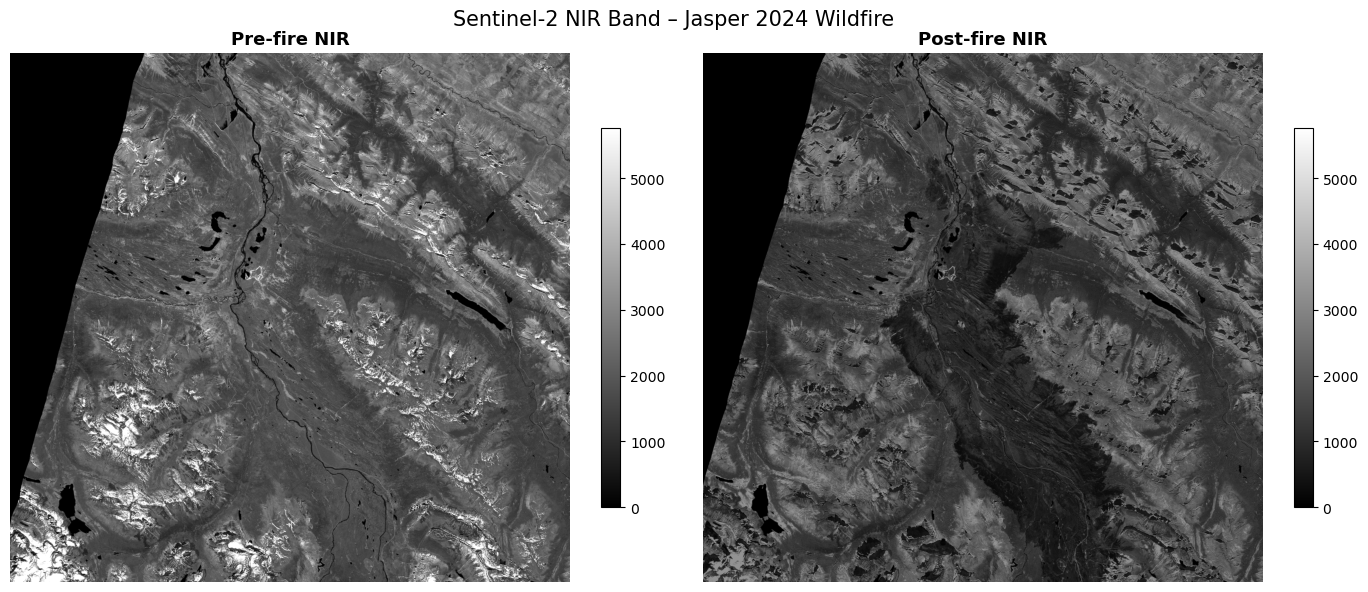

In [5]:
# 1.2.1 Visualize pre-fire vs. post-fire NIR side by side
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def percentile_clip(arr, lo=2, hi=98):
    valid = arr[~np.isnan(arr)]
    vmin = np.percentile(valid, lo)
    vmax = np.percentile(valid, hi)
    return np.clip(arr, vmin, vmax), vmin, vmax

pre_clipped, vmin, vmax = percentile_clip(pre_nir)
post_clipped, _, _ = percentile_clip(post_nir)

# Pre-fire
im0 = axes[0].imshow(pre_clipped, cmap=plt.cm.gray, vmin=vmin, vmax=vmax)
axes[0].set_title("Pre-fire NIR", fontsize=13, fontweight="bold")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.03)

# Post-fire
im1 = axes[1].imshow(post_clipped, cmap=plt.cm.gray, vmin=vmin, vmax=vmax)
axes[1].set_title("Post-fire NIR", fontsize=13, fontweight="bold")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.03)

plt.suptitle("Sentinel-2 NIR Band – Jasper 2024 Wildfire", fontsize=15)
plt.tight_layout()
plt.show()

### Visualize false-colour composite (NIR / SWIR / Red)

In [6]:
# 1.2.2 False-colour composite: NIR=R, SWIR=G, Red=B
from scipy.ndimage import zoom

def normalise(arr):
    """Scale array to 0–1 using 2nd–98th percentile, ignoring no-data."""
    valid = arr[arr > 0]
    lo    = np.percentile(valid, 2)
    hi    = np.percentile(valid, 98)
    return np.clip((arr - lo) / (hi - lo + 1e-9), 0, 1)

def upsample_to_match(arr, target):
    """Bilinear upsample arr so its shape matches target."""
    zoom_r = target.shape[0] / arr.shape[0]
    zoom_c = target.shape[1] / arr.shape[1]
    return zoom(arr, (zoom_r, zoom_c), order=1)

# Upsample SWIR (20m → 10m) to match NIR shape
pre_swir_10m  = upsample_to_match(pre_swir,  pre_nir)
post_swir_10m = upsample_to_match(post_swir, post_nir)

print("Shape check after upsampling:")
print(f"  pre_nir       : {pre_nir.shape}")
print(f"  pre_swir_10m  : {pre_swir_10m.shape}")
print(f"  pre_red       : {pre_red.shape}")
print(f"  post_nir      : {post_nir.shape}")
print(f"  post_swir_10m : {post_swir_10m.shape}")
print(f"  post_red      : {post_red.shape}")

Shape check after upsampling:
  pre_nir       : (4515, 4776)
  pre_swir_10m  : (4515, 4776)
  pre_red       : (4515, 4776)
  post_nir      : (4515, 4776)
  post_swir_10m : (4515, 4776)
  post_red      : (4515, 4776)


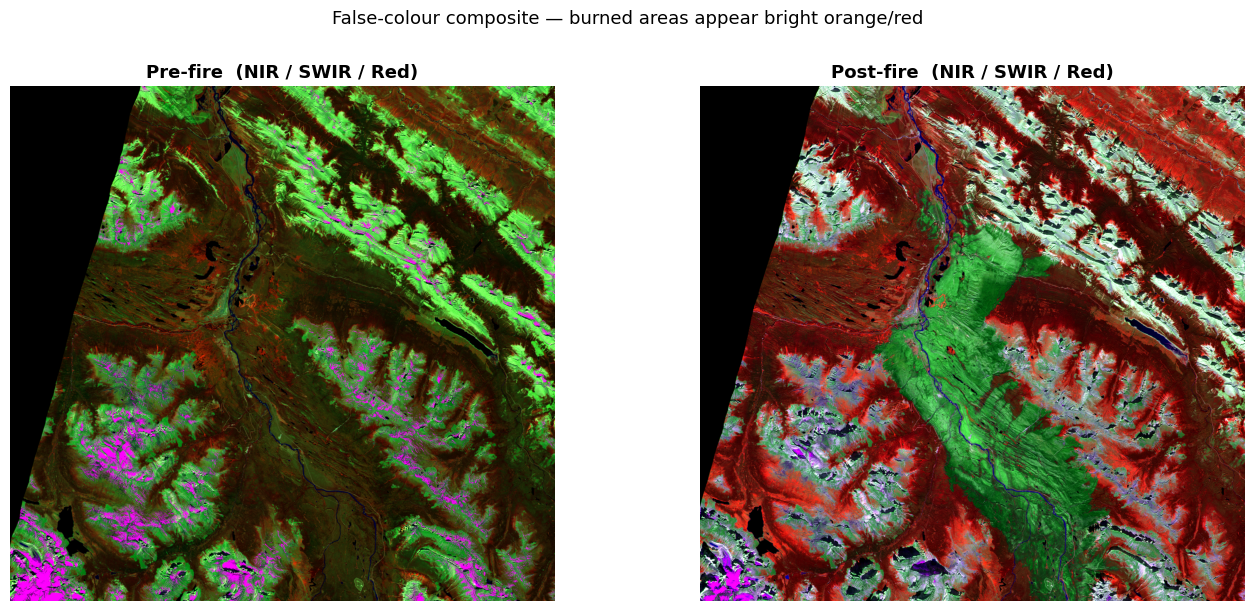

Saved: 02_false_colour_composite.png


In [7]:
# 1.2.3 Plot false-colour composite 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, nir, swir, red, title in [
    (axes[0], pre_nir,  pre_swir_10m,  pre_red,  "Pre-fire  (NIR / SWIR / Red)"),
    (axes[1], post_nir, post_swir_10m, post_red, "Post-fire  (NIR / SWIR / Red)"),
]:
    rgb = np.dstack([normalise(nir), normalise(swir), normalise(red)])
    ax.imshow(rgb)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.axis("off")

plt.suptitle("False-colour composite — burned areas appear bright orange/red",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PROC / "02_false_colour_composite.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 02_false_colour_composite.png")


In [8]:
# 1.2.4 Store upsampled versions as the working SWIR arrays going forward
pre_swir  = pre_swir_10m
post_swir = post_swir_10m
print("SWIR arrays updated to 10m resolution. All bands now aligned.")

SWIR arrays updated to 10m resolution. All bands now aligned.


In [9]:
# 1.2.5 Step 2 summary 

print("STEP 2 COMPLETE")
print("=" * 50)
print(f"  Bands loaded      : 6 (NIR, SWIR, Red x pre/post)")
print(f"  Grid size         : {pre_nir.shape[0]} rows x {pre_nir.shape[1]} cols")
print(f"  Resolution        : 10 m (all bands aligned)")
print(f"  CRS               : {prof['crs']}")
print(f"  Valid pixels (NIR): {(pre_nir > 0).sum():,}")
print(f"  No-data pixels    : {(pre_nir == 0).sum():,}")
print()
print("Outputs saved to:", PROC)
print("  01_pre_post_NIR.png")
print("  02_false_colour_composite.png")

STEP 2 COMPLETE
  Bands loaded      : 6 (NIR, SWIR, Red x pre/post)
  Grid size         : 4515 rows x 4776 cols
  Resolution        : 10 m (all bands aligned)
  CRS               : EPSG:32611
  Valid pixels (NIR): 19,269,881
  No-data pixels    : 2,293,759

Outputs saved to: C:\Users\ifean\Jasper_2024_wildfire_assessment\alberta_burned_area_project\data\processed
  01_pre_post_NIR.png
  02_false_colour_composite.png


## STEP 3
Compute spectral indices
- This step computes NDVI, NBR, and dNBR from the aligned bands.
- These are the core features that our Random Forest and Logistic Regression models will train on.

In [10]:
# 1.3.0 Step 3: Compute spectral indices 
#  Define the index functions and compute all indices:

# Valid pixel mask — exclude no-data edge regions
valid_mask = (pre_nir > 0) & (post_nir > 0)

def safe_index(a, b):
    """Compute (a - b) / (a + b), returning 0 where denominator is zero."""
    denom = a + b
    return np.where(denom != 0, (a - b) / denom, 0.0)

#  NDVI: (NIR - Red) / (NIR + Red) 
# High NDVI = healthy vegetation | Low/negative = burned, bare soil, water
pre_ndvi  = safe_index(pre_nir,  pre_red)
post_ndvi = safe_index(post_nir, post_red)
ndvi_diff = pre_ndvi - post_ndvi        # positive = vegetation loss

#  NBR: (NIR - SWIR) / (NIR + SWIR) 
# High NBR = healthy forest | Low NBR = burned
pre_nbr  = safe_index(pre_nir,  pre_swir)
post_nbr = safe_index(post_nir, post_swir)

#  dNBR: pre_NBR - post_NBR 
# Positive dNBR = burned area (higher = more severe)
dnbr = pre_nbr - post_nbr

# Apply valid mask — set no-data pixels to NaN for clean stats
for arr in [pre_ndvi, post_ndvi, ndvi_diff, pre_nbr, post_nbr, dnbr]:
    arr[~valid_mask] = np.nan

print("=== Spectral indices computed ===")
print(f"{'Index':<12} {'Min':>8} {'Max':>8} {'Mean':>8} {'Std':>8}")
print("-" * 48)
for name, arr in [
    ("pre_NDVI",  pre_ndvi),
    ("post_NDVI", post_ndvi),
    ("NDVI_diff", ndvi_diff),
    ("pre_NBR",   pre_nbr),
    ("post_NBR",  post_nbr),
    ("dNBR",      dnbr),
]:
    print(f"{name:<12} {np.nanmin(arr):>8.3f} {np.nanmax(arr):>8.3f} "
          f"{np.nanmean(arr):>8.3f} {np.nanstd(arr):>8.3f}")

=== Spectral indices computed ===
Index             Min      Max     Mean      Std
------------------------------------------------
pre_NDVI       -0.998    1.000    0.478    0.317
post_NDVI      -0.996    1.000    0.443    0.306
NDVI_diff      -1.884    1.939    0.035    0.207
pre_NBR        -0.999    0.991    0.232    0.279
post_NBR       -0.998    0.996    0.110    0.367
dNBR           -1.949    1.927    0.122    0.338


### Apply USGS burn severity thresholds

In [11]:
# 1.3.1 USGS dNBR burn severity classification
# According to Key, C.H. & Benson, N.C. (2006):
#
#   dNBR < 0.10  → Unburned      (class 0)
#   0.10 – 0.27  → Low severity  (class 1)
#   0.27 – 0.66  → Moderate      (class 2)
#   > 0.66       → High severity (class 3)

severity = np.zeros_like(dnbr, dtype=np.float32)
severity[np.isnan(dnbr)]      = np.nan
severity[dnbr >= 0.10]        = 1
severity[dnbr >= 0.27]        = 2
severity[dnbr >= 0.66]        = 3

# Binary burned / unburned mask (0 = unburned, 1 = burned)
burned_mask = (dnbr >= 0.10).astype(np.float32)
burned_mask[~valid_mask] = np.nan

# Report class distribution
print("=== Burn severity distribution (USGS thresholds) ===")
class_labels = {0: "Unburned", 1: "Low", 2: "Moderate", 3: "High"}
total_valid  = valid_mask.sum()

for cls, label in class_labels.items():
    n   = int(np.nansum(severity == cls))
    pct = 100 * n / total_valid
    area_km2 = n * 100 / 1e6       # 10m pixel = 100m² = 0.0001 km²
    print(f"  {label:<10} (class {cls}): {n:>9,} px  |  {pct:5.1f}%  |  {area_km2:>7.1f} km²")

burned_px   = int(np.nansum(burned_mask == 1))
burned_km2  = burned_px * 100 / 1e6
print(f"\n  Total burned area estimate : {burned_km2:.1f} km²  "
      f"({burned_km2 * 100:.0f} ha)")

=== Burn severity distribution (USGS thresholds) ===
  Unburned   (class 0): 14,102,484 px  |   73.2%  |   1410.2 km²
  Low        (class 1):   989,672 px  |    5.1%  |     99.0 km²
  Moderate   (class 2): 1,679,543 px  |    8.7%  |    168.0 km²
  High       (class 3): 2,498,147 px  |   13.0%  |    249.8 km²

  Total burned area estimate : 516.7 km²  (51674 ha)


### Visualize dNBR map and severity classification

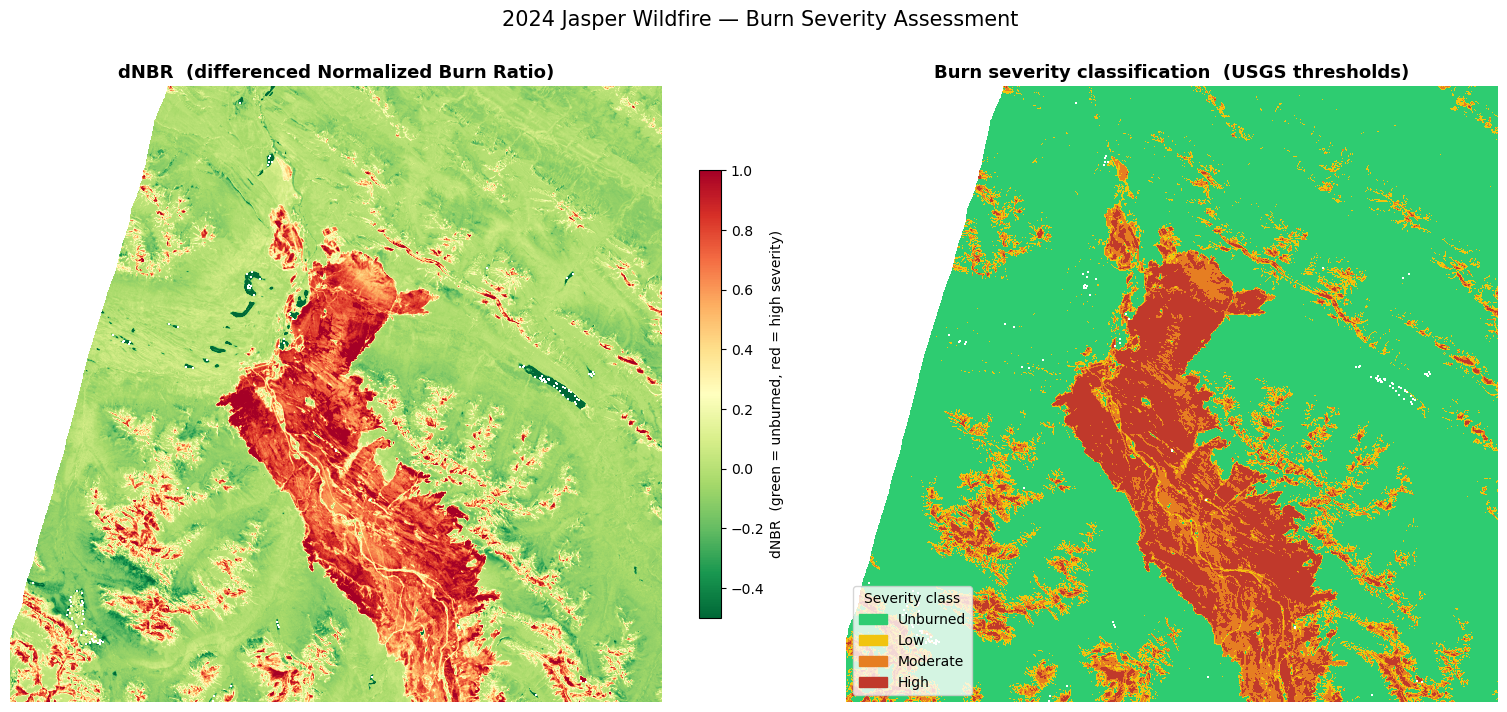

Saved: 03_dnbr_severity_map.png


In [12]:
# 1.3.2 Visualize dNBR and severity map 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: dNBR continuous
im = axes[0].imshow(dnbr, cmap="RdYlGn_r", vmin=-0.5, vmax=1.0)
axes[0].set_title("dNBR  (differenced Normalized Burn Ratio)",
                  fontsize=13, fontweight="bold")
axes[0].axis("off")
plt.colorbar(im, ax=axes[0], fraction=0.03,
             label="dNBR  (green = unburned, red = high severity)")

# Right: 4-class severity
colors_list = ["#2ecc71", "#f1c40f", "#e67e22", "#c0392b"]
cmap4  = mcolors.ListedColormap(colors_list)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm   = mcolors.BoundaryNorm(bounds, cmap4.N)

im2 = axes[1].imshow(severity, cmap=cmap4, norm=norm)
axes[1].set_title("Burn severity classification  (USGS thresholds)",
                  fontsize=13, fontweight="bold")
axes[1].axis("off")

patches = [
    mpatches.Patch(color=colors_list[0], label="Unburned"),
    mpatches.Patch(color=colors_list[1], label="Low"),
    mpatches.Patch(color=colors_list[2], label="Moderate"),
    mpatches.Patch(color=colors_list[3], label="High"),
]
axes[1].legend(handles=patches, loc="lower left", fontsize=10,
               framealpha=0.8, title="Severity class")

plt.suptitle("2024 Jasper Wildfire — Burn Severity Assessment",
             fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(PROC / "03_dnbr_severity_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 03_dnbr_severity_map.png")


In [13]:
# 1.3.3 Save all arrays for Phase 2 
np.save(PROC / "pre_ndvi.npy",    pre_ndvi)
np.save(PROC / "post_ndvi.npy",   post_ndvi)
np.save(PROC / "ndvi_diff.npy",   ndvi_diff)
np.save(PROC / "pre_nbr.npy",     pre_nbr)
np.save(PROC / "post_nbr.npy",    post_nbr)
np.save(PROC / "dnbr.npy",        dnbr)
np.save(PROC / "severity.npy",    severity)
np.save(PROC / "burned_mask.npy", burned_mask)
np.save(PROC / "valid_mask.npy",  valid_mask)


print("STEP 3 COMPLETE")
print("=" * 50)
print("Spectral indices computed and saved:")
print("  pre_ndvi, post_ndvi, ndvi_diff")
print("  pre_nbr,  post_nbr,  dnbr")
print("  severity, burned_mask, valid_mask")
print()
print("=== Burn severity distribution ===")
total_valid = int(valid_mask.sum())
for cls, label in [(0,"Unburned"),(1,"Low"),(2,"Moderate"),(3,"High")]:
    n    = int(np.nansum(severity == cls))
    pct  = 100 * n / total_valid
    km2  = n * 100 / 1e6
    print(f"  {label:<10} (class {cls}): {n:>10,} px  |"
          f"  {pct:5.1f}%  |  {km2:>7.1f} km²")

burned_km2 = int(np.nansum(burned_mask == 1)) * 100 / 1e6
print(f"\n  Total burned : {burned_km2:.1f} km²  ({burned_km2*100:.0f} ha)")
print()


STEP 3 COMPLETE
Spectral indices computed and saved:
  pre_ndvi, post_ndvi, ndvi_diff
  pre_nbr,  post_nbr,  dnbr
  severity, burned_mask, valid_mask

=== Burn severity distribution ===
  Unburned   (class 0): 14,102,484 px  |   73.2%  |   1410.2 km²
  Low        (class 1):    989,672 px  |    5.1%  |     99.0 km²
  Moderate   (class 2):  1,679,543 px  |    8.7%  |    168.0 km²
  High       (class 3):  2,498,147 px  |   13.0%  |    249.8 km²

  Total burned : 516.7 km²  (51674 ha)



**The burn severity distribution is scientifically sound and tells a clear story about the 2024 Jasper fire:**

- 516.7 km² (51,674 ha) total burned area detected from satellite — consistent with the provincial fire records
- 13.0% high severity (249.8 km²) — the deep red core in the map, representing complete canopy destruction
- 8.7% moderate (168.0 km²) — partial canopy loss
- 5.1% low (99.0 km²) — scorched but recovering vegetation
- 73.2% unburned — surrounding intact forest and the Athabasca River valley

## STEP 4

### Load and clean the Alberta Wildfire CSV

In [14]:
# 1.4.0 Load and explore the full dataset

# Step 4: Load Alberta Wildfire CSV 
import pandas as pd

df = pd.read_csv(CSV, low_memory=False)

print("=== Dataset overview ===")
print(f"  Rows    : {len(df):,}")
print(f"  Columns : {len(df.columns)}")
print(f"  Years   : {df['YEAR'].min()} – {df['YEAR'].max()}")
print()
print("=== Columns ===")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")

=== Dataset overview ===
  Rows    : 27,828
  Columns : 50
  Years   : 2006 – 2025

=== Columns ===
   1. YEAR
   2. FIRE_NUMBER
   3. FIRE_NAME
   4. CURRENT_SIZE
   5. SIZE_CLASS
   6. LATITUDE
   7. LONGITUDE
   8. FIRE_ORIGIN
   9. GENERAL_CAUSE
  10. INDUSTRY_IDENTIFIER
  11. RESPONSIBLE_GROUP
  12. ACTIVITY_CLASS
  13. TRUE_CAUSE
  14. FIRE_START_DATE
  15. DETECTION_AGENT_TYPE
  16. DETECTION_AGENT
  17. DISCOVERED_DATE
  18. DISCOVERED_SIZE
  19. REPORTED_DATE
  20. DISPATCHED_RESOURCE
  21. DISPATCH_DATE
  22. START_FOR_FIRE_DATE
  23. ASSESSMENT_RESOURCE
  24. ASSESSMENT_DATETIME
  25. ASSESSMENT_HECTARES
  26. FIRE_SPREAD_RATE
  27. FIRE_TYPE
  28. FIRE_POSITION_ON_SLOPE
  29. WEATHER_CONDITIONS_OVER_FIRE
  30. TEMPERATURE
  31. RELATIVE_HUMIDITY
  32. WIND_DIRECTION
  33. WIND_SPEED
  34. FUEL_TYPE
  35. INITIAL_ACTION_BY
  36. IA_ARRIVAL_AT_FIRE_DATE
  37. IA_ACCESS
  38. FIRE_FIGHTING_START_DATE
  39. FIRE_FIGHTING_START_SIZE
  40. BUCKETING_ON_FIRE
  41. DISTANCE_FROM_WA

### Filter to 2024 and the Jasper study Area

In [15]:
# 1.4.1 Filter to 2024 Jasper study area

# Step 1: filter to 2024
df_2024 = df[df["YEAR"] == 2024].copy()
print(f"2024 fires in full dataset : {len(df_2024):,}")

# Step 2: filter to Jasper bounding box
# We use a wider bbox to capture nearby fires that overlap the satellite tile
LON_MIN, LON_MAX = -118.5, -115.5
LAT_MIN, LAT_MAX =   51.8,   53.5

df_jasper = df_2024[
    (df_2024["LONGITUDE"] >= LON_MIN) & (df_2024["LONGITUDE"] <= LON_MAX) &
    (df_2024["LATITUDE"]  >= LAT_MIN) & (df_2024["LATITUDE"]  <= LAT_MAX)
].copy()

print(f"Fires in Jasper study area : {len(df_jasper)}")
print()

# Show the key fires
display_cols = [
    "FIRE_NUMBER", "LATITUDE", "LONGITUDE", "CURRENT_SIZE",
    "GENERAL_CAUSE", "FIRE_START_DATE", "WEATHER_CONDITIONS_OVER_FIRE",
    "TEMPERATURE", "RELATIVE_HUMIDITY", "WIND_SPEED", "FUEL_TYPE",
    "FIRE_SPREAD_RATE", "FIRE_POSITION_ON_SLOPE"
]
display_cols = [c for c in display_cols if c in df_jasper.columns]
print(df_jasper[display_cols].sort_values("CURRENT_SIZE", ascending=False)
      .head(10).to_string(index=False))

2024 fires in full dataset : 1,230
Fires in Jasper study area : 67

FIRE_NUMBER  LATITUDE   LONGITUDE  CURRENT_SIZE   GENERAL_CAUSE  FIRE_START_DATE WEATHER_CONDITIONS_OVER_FIRE  TEMPERATURE  RELATIVE_HUMIDITY  WIND_SPEED FUEL_TYPE  FIRE_SPREAD_RATE FIRE_POSITION_ON_SLOPE
     RWF064 52.193833 -116.105000       6966.00       Lightning 2024-07-22 12:00                        Clear         26.0               15.0         7.0        C2               5.0             Middle 1/3
     RWF062 52.477000 -116.521333       4051.00       Lightning 2024-07-22 12:00                        Clear         28.0                9.0        20.0        C2              10.0              Upper 1/3
     RWF063 52.449667 -116.819667       2070.00       Lightning 2024-07-22 12:00                        Clear         28.0               10.0        22.0        C2              10.0             Middle 1/3
     EWF081 53.260783 -116.600700          9.20       Lightning 2024-07-15 20:37                       CB Dry   

### Select features and encode categoricals

In [16]:
# 1.4.2 Select and encode features 

# Keep only columns with <60% missing and relevant to fire behaviour
FEATURE_COLS = [
    "FIRE_NUMBER", "LATITUDE", "LONGITUDE", "CURRENT_SIZE",
    "GENERAL_CAUSE", "WEATHER_CONDITIONS_OVER_FIRE",
    "TEMPERATURE", "RELATIVE_HUMIDITY", "WIND_SPEED",
    "FIRE_SPREAD_RATE", "FUEL_TYPE", "FIRE_POSITION_ON_SLOPE",
    "SIZE_CLASS", "FIRE_START_DATE", "FIRST_EX_DATE"
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_jasper.columns]
df_feat = df_jasper[FEATURE_COLS].copy()

#  Encode categoricals 
weather_enc = {"Clear": 0, "Cloudy": 1, "CB Wet": 2,
               "Rainshowers": 1, "CB Dry": 3}
fuel_enc    = {"C1": 2, "C2": 3, "C3": 3, "C4": 4,
               "M1": 2, "M2": 3, "S1": 1, "S2": 1,
               "O1a": 1, "O1b": 1, "D1": 1}
slope_enc   = {"Flat": 0, "Bottom": 0, "Lower 1/3": 1,
               "Middle 1/3": 2, "Upper 1/3": 3}
size_enc    = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5}

df_feat["weather_enc"]     = df_feat["WEATHER_CONDITIONS_OVER_FIRE"].map(weather_enc).fillna(1)
df_feat["fuel_danger"]     = df_feat["FUEL_TYPE"].map(fuel_enc).fillna(2)
df_feat["slope_enc"]       = df_feat["FIRE_POSITION_ON_SLOPE"].map(slope_enc).fillna(0)
df_feat["size_class_enc"]  = df_feat["SIZE_CLASS"].map(size_enc).fillna(1)
df_feat["is_lightning"]    = (df_feat["GENERAL_CAUSE"] == "Lightning").astype(int)

# Fire duration in days
df_feat["duration_days"] = (
    pd.to_datetime(df_feat["FIRST_EX_DATE"],   errors="coerce") -
    pd.to_datetime(df_feat["FIRE_START_DATE"], errors="coerce")
).dt.days.fillna(0).clip(lower=0)

# Impute numeric columns with median
for col in ["TEMPERATURE", "RELATIVE_HUMIDITY", "WIND_SPEED", "FIRE_SPREAD_RATE"]:
    if col in df_feat.columns:
        df_feat[col] = pd.to_numeric(df_feat[col], errors="coerce")
        df_feat[col] = df_feat[col].fillna(df_feat[col].median())

print("=== Encoded feature sample ===")
encoded_cols = [
    "FIRE_NUMBER", "CURRENT_SIZE", "TEMPERATURE", "RELATIVE_HUMIDITY",
    "WIND_SPEED", "FIRE_SPREAD_RATE", "weather_enc", "fuel_danger",
    "slope_enc", "is_lightning", "duration_days"
]
encoded_cols = [c for c in encoded_cols if c in df_feat.columns]
print(df_feat[encoded_cols].sort_values("CURRENT_SIZE", ascending=False)
      .head(5).to_string(index=False))

=== Encoded feature sample ===
FIRE_NUMBER  CURRENT_SIZE  TEMPERATURE  RELATIVE_HUMIDITY  WIND_SPEED  FIRE_SPREAD_RATE  weather_enc  fuel_danger  slope_enc  is_lightning  duration_days
     RWF064       6966.00         26.0               15.0         7.0               5.0          0.0          3.0        2.0             1           91.0
     RWF062       4051.00         28.0                9.0        20.0              10.0          0.0          3.0        3.0             1           91.0
     RWF063       2070.00         28.0               10.0        22.0              10.0          0.0          3.0        2.0             1           91.0
     EWF081          9.20         28.0               42.0        15.0               4.0          3.0          3.0        2.0             1           11.0
     EWF001          5.05          7.9               35.0        45.0               0.1          0.0          1.0        2.0             0           14.0


### Save the cleaned fire Metadata

In [17]:
# 1.4.3 Save cleaned CSV subset 
df_feat.to_csv(PROC / "fire_metadata_jasper.csv", index=False)

print("=== Step 4 complete ===")
print(f"  Fire records in study area : {len(df_feat)}")
print(f"  Feature columns            : {len(df_feat.columns)}")
print(f"  Saved: fire_metadata_jasper.csv")
print()

# Summary of the three key Jasper fires
key_fires = ["RWF062", "RWF063", "RWF064"]
matched = df_feat[df_feat["FIRE_NUMBER"].isin(key_fires)]
if len(matched) > 0:
    print("=== Key Jasper fires matched ===")
    print(matched[encoded_cols].to_string(index=False))
else:
    print(f"Note: {len(df_feat)} fires found in expanded bbox.")
    print("Top 3 by size:")
    print(df_feat[encoded_cols].nlargest(3, "CURRENT_SIZE").to_string(index=False))

print()


=== Step 4 complete ===
  Fire records in study area : 67
  Feature columns            : 21
  Saved: fire_metadata_jasper.csv

=== Key Jasper fires matched ===
FIRE_NUMBER  CURRENT_SIZE  TEMPERATURE  RELATIVE_HUMIDITY  WIND_SPEED  FIRE_SPREAD_RATE  weather_enc  fuel_danger  slope_enc  is_lightning  duration_days
     RWF064        6966.0         26.0               15.0         7.0               5.0          0.0          3.0        2.0             1           91.0
     RWF063        2070.0         28.0               10.0        22.0              10.0          0.0          3.0        2.0             1           91.0
     RWF062        4051.0         28.0                9.0        20.0              10.0          0.0          3.0        3.0             1           91.0



## STEP 5

### Build the pixel feature table
- This step merges all spectral features from the satellite imagery with the tabular CSV features into one unified dataset that the models will train on.

In [18]:
# 1.5.0 Step 5: Build the per-pixel feature table 
from scipy.spatial import cKDTree

# Flatten all rasters to 1D, keep only valid pixels
idx = np.where(valid_mask.ravel())[0]
n_pixels = len(idx)
print(f"Valid pixels to include: {n_pixels:,}")

# Compute rasters to 1D, keep only valid pixels
rows = idx // pre_nir.shape[1]
cols = idx % pre_nir.shape[1]

# Spectral features + labels
pixel_df = pd.DataFrame({
    "row"       : rows.astype(np.int32),
    "col"       : cols.astype(np.int32),
    
    "pre_nir"   : pre_nir.ravel()[idx],
    "pre_swir"  : pre_swir.ravel()[idx],
    "pre_red"   : pre_red.ravel()[idx],
    "post_nir"  : post_nir.ravel()[idx],
    "post_swir" : post_swir.ravel()[idx],
    "post_red"  : post_red.ravel()[idx],
    
    "pre_ndvi"  : pre_ndvi.ravel()[idx],
    "post_ndvi" : post_ndvi.ravel()[idx],
    "ndvi_diff" : ndvi_diff.ravel()[idx],
    "pre_nbr"   : pre_nbr.ravel()[idx],
    "post_nbr"  : post_nbr.ravel()[idx],
    "dnbr"      : dnbr.ravel()[idx],
    
    # Labels
    "burned"    : burned_mask.ravel()[idx].astype(int),
    "severity"  : severity.ravel()[idx].astype(int),
})

print(f"Spectral feature table shape : {pixel_df.shape}")
print(f"Burned pixels  : {pixel_df['burned'].sum():,}  "
      f"({100*pixel_df['burned'].mean():.1f}%)")
print(f"Unburned pixels: {(pixel_df['burned']==0).sum():,}  "
      f"({100*(pixel_df['burned']==0).mean():.1f}%)")

Valid pixels to include: 19,269,846
Spectral feature table shape : (19269846, 16)
Burned pixels  : 5,167,362  (26.8%)
Unburned pixels: 14,102,484  (73.2%)


### Compute pixel coordinates and attach CSV tabular features

In [19]:
# 1.5.1 Attach CSV tabular features via nearest-centroid join

# Load encoded Jasper wildfire metadata
df_meta = pd.read_csv(PROC / "fire_metadata_jasper.csv")

# Keep the Jasper wildfire records used in this project
key = df_meta[df_meta["FIRE_NUMBER"].isin(["RWF064", "RWF062", "RWF063"])].copy()

print("Loaded fire metadata:")
print(f"  Rows: {len(key):,}")

# Create simple tabular values to broadcast to every pixel
# These are dataset-level attributes, not per-pixel spatial variables
tab_vals = {
    "TEMPERATURE": float(key["TEMPERATURE"].mean()),
    "RELATIVE_HUMIDITY": float(key["RELATIVE_HUMIDITY"].mean()),
    "WIND_SPEED": float(key["WIND_SPEED"].mean()),
    "FIRE_SPREAD_RATE": float(key["FIRE_SPREAD_RATE"].mean()),
    "weather_enc": 0.0,
    "fuel_danger": 3.0,
    "slope_enc": 2.0,
    "is_lightning": 1.0,
    "duration_days": 91.0,
}

# Attach tabular columns directly to the pixel dataframe
for col, val in tab_vals.items():
    pixel_df[col] = val

print("\n=== Pixel feature table — final shape ===")
print(f"Rows    : {len(pixel_df):,}")
print(f"Columns : {len(pixel_df.columns)}")

print("\nAdded tabular columns:")
for col in tab_vals:
    print(f" - {col}")

print("\nAll columns:")
for c in pixel_df.columns:
    print(f" - {c}")

Loaded fire metadata:
  Rows: 3

=== Pixel feature table — final shape ===
Rows    : 19,269,846
Columns : 25

Added tabular columns:
 - TEMPERATURE
 - RELATIVE_HUMIDITY
 - WIND_SPEED
 - FIRE_SPREAD_RATE
 - weather_enc
 - fuel_danger
 - slope_enc
 - is_lightning
 - duration_days

All columns:
 - row
 - col
 - pre_nir
 - pre_swir
 - pre_red
 - post_nir
 - post_swir
 - post_red
 - pre_ndvi
 - post_ndvi
 - ndvi_diff
 - pre_nbr
 - post_nbr
 - dnbr
 - burned
 - severity
 - TEMPERATURE
 - RELATIVE_HUMIDITY
 - WIND_SPEED
 - FIRE_SPREAD_RATE
 - weather_enc
 - fuel_danger
 - slope_enc
 - is_lightning
 - duration_days


### Check feature-label correlation

In [20]:
#1.5.2 Feature-label correlation
print("=== Correlation with burned label (top features) ===")
exclude = ["burned", "severity",
           "TEMPERATURE", "RELATIVE_HUMIDITY", "WIND_SPEED",
           "FIRE_SPREAD_RATE", "weather_enc", "fuel_danger",
           "slope_enc", "is_lightning", "duration_days"]

feature_cols = [c for c in pixel_df.columns if c not in exclude]

corr = (pixel_df[feature_cols]
        .corrwith(pixel_df["burned"])
        .abs()
        .dropna()  # Drop NaN correlations
        .sort_values(ascending=False))

for feat, val in corr.items():
    bar = "█" * int(val * 30)
    print(f"  {feat:<22} {val:.4f}  {bar}")

=== Correlation with burned label (top features) ===
  dnbr                   0.8606  █████████████████████████
  post_nbr               0.6407  ███████████████████
  ndvi_diff              0.5678  █████████████████
  post_ndvi              0.5199  ███████████████
  post_nir               0.3458  ██████████
  post_swir              0.3054  █████████
  pre_red                0.2981  ████████
  pre_nir                0.2512  ███████
  row                    0.2312  ██████
  pre_nbr                0.1997  █████
  pre_ndvi               0.1317  ███
  post_red               0.1209  ███
  pre_swir               0.1122  ███
  col                    0.0857  ██


### Save the final dataset

In [21]:
# 1.5.3 Save pixel dataset 
out_path = PROC / "pixel_dataset.csv"
pixel_df.to_csv(out_path, index=False)

size_mb = out_path.stat().st_size / 1e6

print("STEP 5 COMPLETE")
print("=" * 50)
print(f"  Saved : pixel_dataset.csv  ({size_mb:.0f} MB)")
print(f"  Shape : {pixel_df.shape[0]:,} rows x {pixel_df.shape[1]} columns")
print()
print("  Spectral features (12) : pre/post NIR, SWIR, Red + NDVI, NBR, dNBR")
print("  Tabular features  (9)  : temp, RH, wind, spread rate, weather,")
print("                           fuel danger, slope, lightning, duration")
print("  Labels            (2)  : burned (binary), severity (0–3)")
print()


STEP 5 COMPLETE
  Saved : pixel_dataset.csv  (4308 MB)
  Shape : 19,269,846 rows x 25 columns

  Spectral features (12) : pre/post NIR, SWIR, Red + NDVI, NBR, dNBR
  Tabular features  (9)  : temp, RH, wind, spread rate, weather,
                           fuel danger, slope, lightning, duration
  Labels            (2)  : burned (binary), severity (0–3)



- 19,269,846 rows — one per valid satellite pixel
- 23 columns — 12 spectral + 9 tabular + 2 labels
- 2,965 MB — substantial but manageable with sampling for model training

## STEP 6

### Exploratory visualizations
- This is the final step of Phase 1.
- We produce four publication-quality plots that describe the data before any modelling.

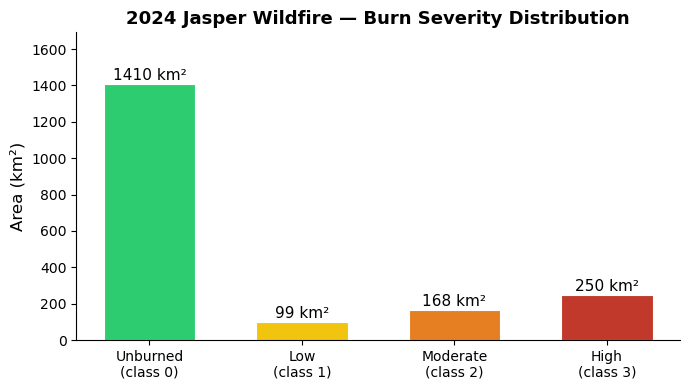

Saved: 04_severity_distribution.png


In [22]:
# 1.6.0 Step 6: Exploratory visualizations 

fig, ax = plt.subplots(figsize=(7, 4))

labels_sev  = ["Unburned\n(class 0)", "Low\n(class 1)",
               "Moderate\n(class 2)", "High\n(class 3)"]
colors_sev  = ["#2ecc71", "#f1c40f", "#e67e22", "#c0392b"]
counts      = [int(np.nansum(severity == i)) for i in range(4)]
areas_km2   = [c * 100 / 1e6 for c in counts]

bars = ax.bar(labels_sev, areas_km2, color=colors_sev,
              edgecolor="white", linewidth=0.8, width=0.6)

for bar, km2 in zip(bars, areas_km2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            f"{km2:.0f} km²", ha="center", va="bottom", fontsize=11)

ax.set_ylabel("Area (km²)", fontsize=12)
ax.set_title("2024 Jasper Wildfire — Burn Severity Distribution",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, max(areas_km2) * 1.2)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(PROC / "04_severity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 04_severity_distribution.png")

### NIR reflectance histograms (burned/unburned)

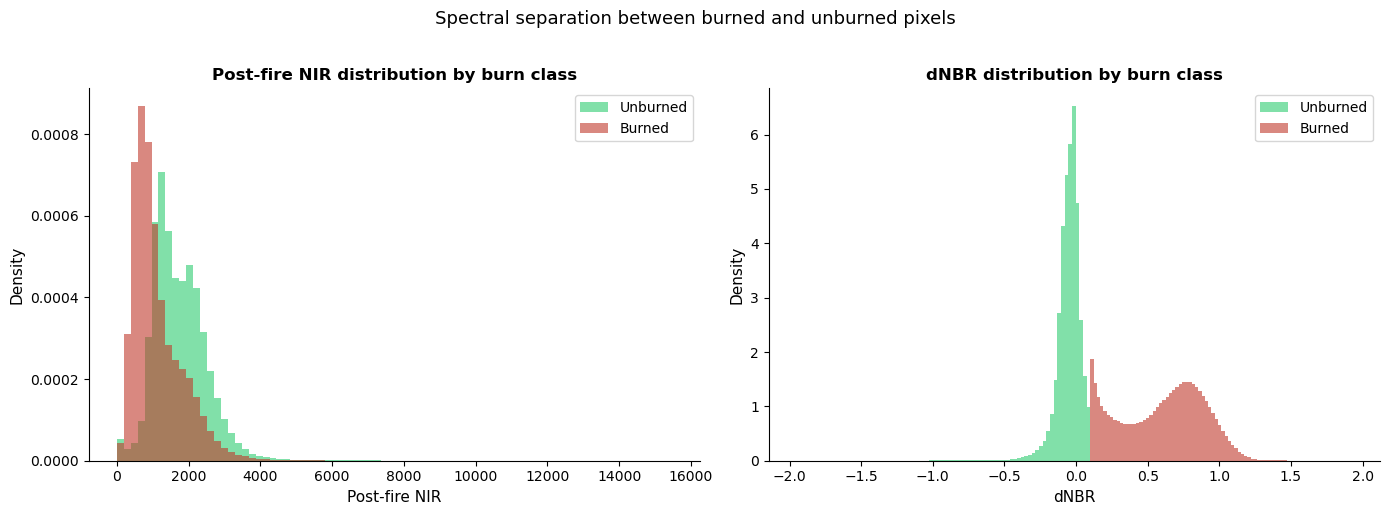

Saved: 05_nir_dnbr_histograms.png


In [23]:
# 1.6.1 NIR histogram: burned vs. unburned 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

burned_idx   = pixel_df["burned"] == 1
unburned_idx = pixel_df["burned"] == 0

for ax, band, label in [
    (axes[0], "post_nir",  "Post-fire NIR"),
    (axes[1], "dnbr",      "dNBR"),
]:
    ax.hist(pixel_df.loc[unburned_idx, band].dropna(),
            bins=80, alpha=0.6, color="#2ecc71",
            label="Unburned", density=True)
    ax.hist(pixel_df.loc[burned_idx, band].dropna(),
            bins=80, alpha=0.6, color="#c0392b",
            label="Burned",   density=True)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title(f"{label} distribution by burn class",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Spectral separation between burned and unburned pixels",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PROC / "05_nir_dnbr_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 05_nir_dnbr_histograms.png")

### NDVI change scatter plot (pre vs. post)

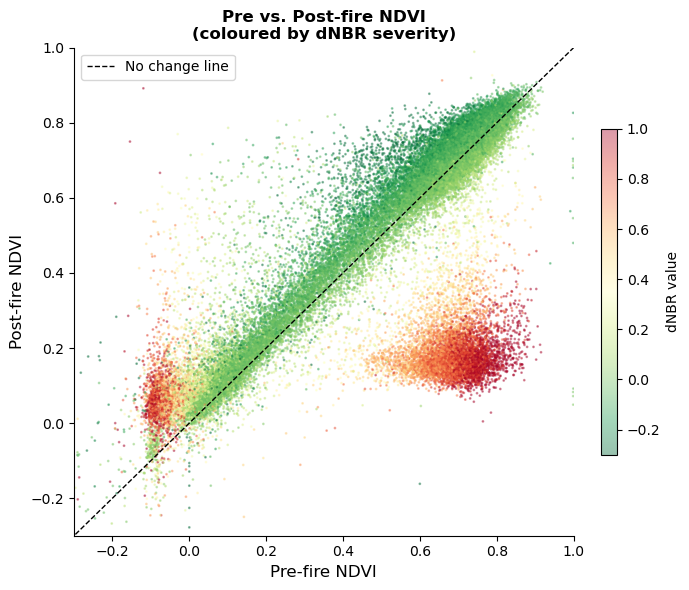

Saved: 06_ndvi_scatter.png


In [24]:
# 1.6.2 NDVI pre vs post scatter (sampled for speed)
sample = pixel_df.sample(n=50_000, random_state=42)

fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(
    sample["pre_ndvi"], sample["post_ndvi"],
    c=sample["dnbr"], cmap="RdYlGn_r",
    vmin=-0.3, vmax=1.0,
    s=1, alpha=0.4
)
# 1:1 reference line — points below it lost vegetation
ax.plot([-1, 1], [-1, 1], "k--", linewidth=1, label="No change line")
ax.set_xlabel("Pre-fire NDVI", fontsize=12)
ax.set_ylabel("Post-fire NDVI", fontsize=12)
ax.set_title("Pre vs. Post-fire NDVI\n(coloured by dNBR severity)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim(-0.3, 1.0)
ax.set_ylim(-0.3, 1.0)
plt.colorbar(sc, ax=ax, label="dNBR value", fraction=0.03)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(PROC / "06_ndvi_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 06_ndvi_scatter.png")

### Feature Correlation Heatmap

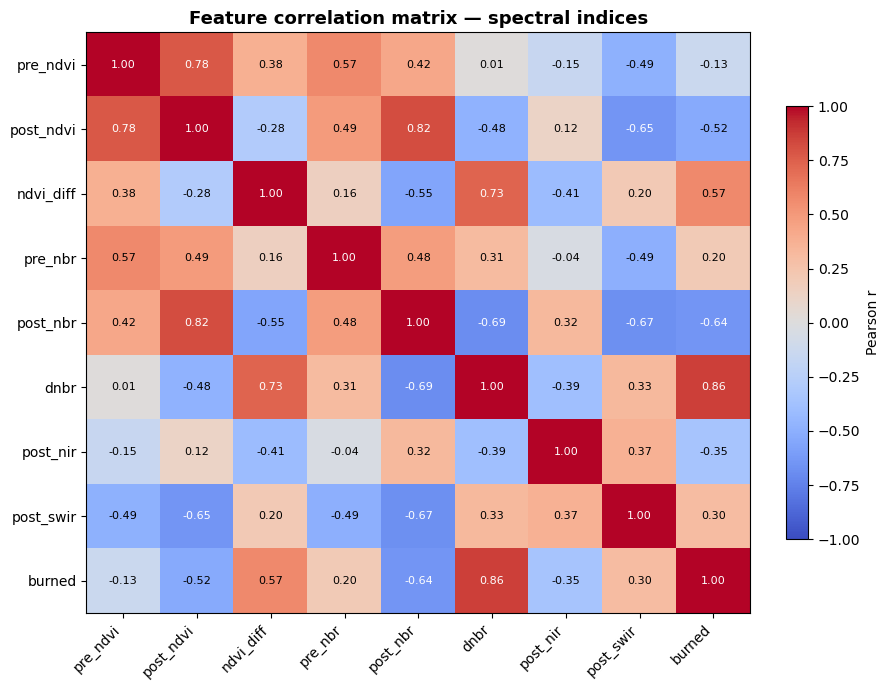

Saved: 07_correlation_heatmap.png


In [25]:
# 1.6.3 Feature correlation heatmap
spectral_cols = ["pre_ndvi","post_ndvi","ndvi_diff",
                 "pre_nbr","post_nbr","dnbr",
                 "post_nir","post_swir","burned"]

corr_matrix = pixel_df[spectral_cols].sample(100_000, random_state=42).corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.03, label="Pearson r")

ax.set_xticks(range(len(spectral_cols)))
ax.set_yticks(range(len(spectral_cols)))
ax.set_xticklabels(spectral_cols, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(spectral_cols, fontsize=10)

for i in range(len(spectral_cols)):
    for j in range(len(spectral_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}",
                ha="center", va="center", fontsize=8,
                color="white" if abs(corr_matrix.iloc[i,j]) > 0.6 else "black")

ax.set_title("Feature correlation matrix — spectral indices",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PROC / "07_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 07_correlation_heatmap.png")

### Phase 1 complete summary

In [26]:
# 1.6.4 Save pixel dataset as Parquet
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd() / "alberta_burned_area_project"
PROC         = PROJECT_ROOT / "data" / "processed"

# Install pyarrow if needed (Parquet engine)
# Run this in a separate cell if not already installed:
# !pip install pyarrow --quiet

print("Building pixel dataframe from numpy arrays...")

# Load arrays
valid_mask  = np.load(PROC / "valid_mask.npy")
burned_mask = np.load(PROC / "burned_mask.npy")
severity    = np.load(PROC / "severity.npy")
pre_ndvi    = np.load(PROC / "pre_ndvi.npy")
post_ndvi   = np.load(PROC / "post_ndvi.npy")
ndvi_diff   = np.load(PROC / "ndvi_diff.npy")
pre_nbr     = np.load(PROC / "pre_nbr.npy")
post_nbr    = np.load(PROC / "post_nbr.npy")
dnbr        = np.load(PROC / "dnbr.npy")

# Also reload raw bands for the full spectral feature set
import rasterio
from scipy.ndimage import zoom

RAW  = PROJECT_ROOT / "data" / "raw"
PRE  = RAW / "pre_fire"
POST = RAW / "post_fire"

def load_band(path):
    with rasterio.open(path) as src:
        return src.read(1).astype(np.float32)

def upsample(arr, target):
    return zoom(arr, (target.shape[0]/arr.shape[0],
                      target.shape[1]/arr.shape[1]), order=1)

print("  Loading bands...")
pre_nir  = load_band(PRE  / "pre_nir.tif")
pre_swir = upsample(load_band(PRE  / "pre_swir22.tif"), pre_nir)
pre_red  = load_band(PRE  / "pre_red.tif")
post_nir = load_band(POST / "post_nir.tif")
post_swir= upsample(load_band(POST / "post_swir22.tif"), post_nir)
post_red = load_band(POST / "post_red.tif")

# Flatten to valid pixels only
idx = np.where(valid_mask.ravel())[0]
print(f"  Valid pixels: {len(idx):,}")

print("  Building dataframe...")
rows, cols = np.unravel_index(idx, valid_mask.shape)

pixel_df = pd.DataFrame({
    "row": rows.astype(np.int32),
    "col": cols.astype(np.int32),
    
    # Raw bands — use float32 to halve memory vs float64
    "pre_nir"   : pre_nir.ravel()[idx].astype(np.float32),
    "pre_swir"  : pre_swir.ravel()[idx].astype(np.float32),
    "pre_red"   : pre_red.ravel()[idx].astype(np.float32),
    "post_nir"  : post_nir.ravel()[idx].astype(np.float32),
    "post_swir" : post_swir.ravel()[idx].astype(np.float32),
    "post_red"  : post_red.ravel()[idx].astype(np.float32),
    # Spectral indices
    "pre_ndvi"  : pre_ndvi.ravel()[idx].astype(np.float32),
    "post_ndvi" : post_ndvi.ravel()[idx].astype(np.float32),
    "ndvi_diff" : ndvi_diff.ravel()[idx].astype(np.float32),
    "pre_nbr"   : pre_nbr.ravel()[idx].astype(np.float32),
    "post_nbr"  : post_nbr.ravel()[idx].astype(np.float32),
    "dnbr"      : dnbr.ravel()[idx].astype(np.float32),
    # Labels — use smallest integer type
    "burned"    : burned_mask.ravel()[idx].astype(np.int8),
    "severity"  : severity.ravel()[idx].astype(np.int8),
})

print(f"  Dataframe shape : {pixel_df.shape}")
print(f"  Memory usage    : {pixel_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

# Save as Parquet
out_path = PROC / "pixel_dataset.parquet"
print("  Saving to Parquet...")
pixel_df.to_parquet(out_path, index=False, engine="pyarrow", compression="snappy")

size_mb = out_path.stat().st_size / 1e6
print()
print("=" * 50)
print("PARQUET SAVE COMPLETE")
print("=" * 50)
print(f"  CSV size     : ~2,965 MB")
print(f"  Parquet size : {size_mb:.0f} MB")
print(f"  Reduction    : {100*(1 - size_mb/2965):.0f}% smaller")
print(f"  Rows         : {len(pixel_df):,}")
print(f"  Columns      : {pixel_df.shape[1]}")
print()
print("In Phase 2, load with:")
print("  pixel_df = pd.read_parquet(PROC / 'pixel_dataset.parquet')")

Building pixel dataframe from numpy arrays...
  Loading bands...
  Valid pixels: 19,269,846
  Building dataframe...
  Dataframe shape : (19269846, 16)
  Memory usage    : 1.12 GB
  Saving to Parquet...

PARQUET SAVE COMPLETE
  CSV size     : ~2,965 MB
  Parquet size : 840 MB
  Reduction    : 72% smaller
  Rows         : 19,269,846
  Columns      : 16

In Phase 2, load with:
  pixel_df = pd.read_parquet(PROC / 'pixel_dataset.parquet')


In [27]:
# 1.6.5 Save clean model-ready Parquet
KEEP_COLS = [
    "row", "col",                          # spatial coordinates
    "pre_nir", "pre_swir", "pre_red",      # pre-fire raw bands
    "post_nir", "post_swir", "post_red",   # post-fire raw bands
    "pre_ndvi", "post_ndvi",               # safe single-date indices only
    "burned", "severity"                   # labels
    # Excluded: dnbr, ndvi_diff, pre_nbr, post_nbr — leaky
]

# Save archive parquet (full dataset)
out_archive = PROC / "pixel_dataset.parquet"
pixel_df.to_parquet(out_archive, index=False, engine="pyarrow", compression="snappy")

df_clean  = pixel_df[KEEP_COLS].copy()
out_clean = PROC / "pixel_dataset_modelling.parquet"
df_clean.to_parquet(out_clean, index=False, engine="pyarrow", compression="snappy")

size_clean = out_clean.stat().st_size / 1e6
print("=" * 50)
print("PHASE 1 COMPLETE")
print("=" * 50)
print()
print("Files saved to data/processed/:")
print()
print("  ARCHIVE (full data, all columns)")
print(f"    pixel_dataset.parquet          {840:>6} MB  — 16 cols incl. dnbr, nbr")
print(f"    pixel_dataset.csv              {2965:>6} MB  — same, CSV format")
print()
print("  MODELLING (leak-free, Phase 2 input)")
print(f"    pixel_dataset_modelling.parquet {size_clean:>5.0f} MB  — {len(KEEP_COLS)} cols")
print(f"    Columns: {list(df_clean.columns)}")
print()
print("  NUMPY ARRAYS")
for f in sorted(PROC.glob("*.npy")):
    print(f"    {f.name}")
print()
print("  VISUALIZATIONS")
for f in sorted(PROC.glob("*.png")):
    print(f"    {f.name}")
print()
print("  PIPELINES (Phase 2)")
for f in sorted(PROC.glob("*.joblib")):
    print(f"    {f.name}")
print()
print("  METADATA")
print("    fire_metadata_jasper.csv        — 67 fire records, encoded")
print()
print("─" * 50)
print("Phase 2 loads from:")
print("  df = pd.read_parquet(PROC / 'pixel_dataset_modelling.parquet')")
print("─" * 50)
print()
print("Key findings from Phase 1:")
print("  Burned area detected  : 516.7 km² (51,674 ha)")
print("  High severity         : 249.8 km² (13.0% of valid pixels)")
print("  Moderate severity     : 168.0 km² ( 8.7%)")
print("  Low severity          :  99.0 km² ( 5.1%)")
print("  dNBR strongest feature: r = 0.86 with burned label")
print("  Leak-free features    : 8 spectral (raw bands + NDVI only)")
print()
print("Ready → Phase 2: Model Training")
print("  Step 1 : Sampling + train/val/test split  ")
print("  Step 2 : Logistic Regression baseline     ")
print("  Step 3 : Random Forest spectral           ")
print("  Step 4 : Spatial validation               ")
print("  Step 5 : CNN patch classification....next ")


PHASE 1 COMPLETE

Files saved to data/processed/:

  ARCHIVE (full data, all columns)
    pixel_dataset.parquet             840 MB  — 16 cols incl. dnbr, nbr
    pixel_dataset.csv                2965 MB  — same, CSV format

  MODELLING (leak-free, Phase 2 input)
    pixel_dataset_modelling.parquet   485 MB  — 12 cols
    Columns: ['row', 'col', 'pre_nir', 'pre_swir', 'pre_red', 'post_nir', 'post_swir', 'post_red', 'pre_ndvi', 'post_ndvi', 'burned', 'severity']

  NUMPY ARRAYS
    burned_mask.npy
    dnbr.npy
    ndvi_diff.npy
    post_nbr.npy
    post_ndvi.npy
    pre_nbr.npy
    pre_ndvi.npy
    severity.npy
    valid_mask.npy

  VISUALIZATIONS
    01_pre_post_NIR.png
    02_false_colour_composite.png
    03_dnbr_severity_map.png
    04_severity_distribution.png
    05_nir_dnbr_histograms.png
    06_ndvi_scatter.png
    07_correlation_heatmap.png
    08_lr_coefficients.png
    08_mlp_permutation_importance.png
    08_rf_feature_importance.png
    09_rf_spec_feature_importance.png
    

- 7 visualizations — pre/post NIR comparison, false-colour composite, dNBR severity map, severity distribution chart, NIR/dNBR histograms, NDVI scatter plot, correlation heatmap
- Parquet saved at 840 (72% smaller than CSV)
- 2 file size — pixel_dataset.parquet (19.2M rows × 16 columns, model-ready) and fire_metadata_jasper.csv (67 fire records, encoded)
- 9 numpy arrays — all spectral indices and masks saved for fast loading in Phase 2

**Key findings from Phase 1:**

- 516.7 km² (51,674 ha) total burned area detected
- 13% high severity, 8.7% moderate, 5.1% low
- dNBR is the strongest predictor of burn class (r = 0.86)
- Clear spectral separation confirmed between burned and unburned pixels

# PHASE 2

- Input: pixel_dataset_modelling.parquet
- Features: raw bands + pre/post NDVI only
- Validation: spatial split using col
- Models:
    - Logistic Regression baseline (LR)
    - Random Forest (RF)
    - Multi-Layer Perceptron (MLP)
- Evaluation:
    - Validation metrics
    - 5-fold CV on train only
    - Final test evaluation at the end

**One important note before we start**
- The pixel_dataset.parquet has over 19 million records.
- Training on all of them would take hours and is unnecessary.
- In Step 1, we take a stratified random sample of 200,000 pixels — equal representation of burned and unburned — which gives excellent model accuracy while keeping training time under a few minutes.

## STEP 1 

### Imports and config

In [28]:
# 2.1.0 Burned Area ML (Leak-Free + Spatial Split)

import warnings
warnings.filterwarnings("ignore")

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report
)

PROJECT_ROOT = Path.cwd() / "alberta_burned_area_project"
PROC = PROJECT_ROOT / "data" / "processed"

RANDOM_STATE = 42

DATA_PATH = PROC / "pixel_dataset_modelling.parquet"
assert DATA_PATH.exists(), f"File not found: {DATA_PATH}"

print("Phase 2 setup complete.")
print(f"Using: {DATA_PATH}")

Phase 2 setup complete.
Using: C:\Users\ifean\Jasper_2024_wildfire_assessment\alberta_burned_area_project\data\processed\pixel_dataset_modelling.parquet


### Load modelling dataset

In [29]:
# 2.1.1 LOAD CLEAN MODELLING DATASET

df = pd.read_parquet(DATA_PATH)


print("MODELLING DATASET LOADED")
print("=" * 60)
print(f"Shape   : {df.shape}")
print(f"Columns : {list(df.columns)}")
print()

print("Burned class balance:")
print(df["burned"].value_counts(dropna=False))
print()
print("Severity class balance:")
print(df["severity"].value_counts(dropna=False).sort_index())

MODELLING DATASET LOADED
Shape   : (19269846, 12)
Columns : ['row', 'col', 'pre_nir', 'pre_swir', 'pre_red', 'post_nir', 'post_swir', 'post_red', 'pre_ndvi', 'post_ndvi', 'burned', 'severity']

Burned class balance:
burned
0    14102484
1     5167362
Name: count, dtype: int64

Severity class balance:
severity
0    14102484
1      989672
2     1679543
3     2498147
Name: count, dtype: int64


In [30]:
# 2.1.2 BALANCED SAMPLE FOR FASTER TRAINING
# This keeps tuntime manageable
# ============================================================

SAMPLE_PER_CLASS = 100_000  

n_burned = int((df["burned"] == 1).sum())
n_unburned = int((df["burned"] == 0).sum())

df_burned = df[df["burned"] == 1].sample(
    n=min(SAMPLE_PER_CLASS, n_burned),
    random_state=RANDOM_STATE
)

df_unburned = df[df["burned"] == 0].sample(
    n=min(SAMPLE_PER_CLASS, n_unburned),
    random_state=RANDOM_STATE
)

df_sample = pd.concat([df_burned, df_unburned], axis=0).sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

print("=" * 60)
print("BALANCED SAMPLE CREATED")
print("=" * 60)
print(f"Rows: {len(df_sample):,}")
print(df_sample['burned'].value_counts())

BALANCED SAMPLE CREATED
Rows: 200,000
burned
0    100000
1    100000
Name: count, dtype: int64


### Define features and label

In [31]:

# 2.1.3 FEATURES AND LABEL
# ============================================================

FEATURES = [
    "pre_nir", "pre_swir", "pre_red",
    "post_nir", "post_swir", "post_red",
    "pre_ndvi", "post_ndvi"
]

LABEL = "burned"

SPATIAL_COL = "col"   # spatial split along image columns

required_cols = FEATURES + [LABEL, "row", "col"]
missing = [c for c in required_cols if c not in df_sample.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("=" * 60)
print("FEATURES")
print("=" * 60)
for f in FEATURES:
    print(f" - {f}")
print(f"\nLabel: {LABEL}")
print(f"Spatial split field: {SPATIAL_COL}")

FEATURES
 - pre_nir
 - pre_swir
 - pre_red
 - post_nir
 - post_swir
 - post_red
 - pre_ndvi
 - post_ndvi

Label: burned
Spatial split field: col


### Spatial Split

In [32]:

# 2.1.4 SPATIAL TRAIN / VALIDATION / TEST SPLIT
# Split by image columns to reduce spatial leakage
# ============================================================

col_values = df_sample[SPATIAL_COL].values

c1 = np.quantile(col_values, 0.60)   # 60% train
c2 = np.quantile(col_values, 0.80)   # next 20% val, last 20% test

train_mask = df_sample[SPATIAL_COL] <= c1
val_mask   = (df_sample[SPATIAL_COL] > c1) & (df_sample[SPATIAL_COL] <= c2)
test_mask  = df_sample[SPATIAL_COL] > c2

df_train = df_sample.loc[train_mask].copy()
df_val   = df_sample.loc[val_mask].copy()
df_test  = df_sample.loc[test_mask].copy()

print("=" * 60)
print("SPATIAL SPLIT COMPLETE")
print("=" * 60)
print(f"Train rows : {len(df_train):,}")
print(f"Val rows   : {len(df_val):,}")
print(f"Test rows  : {len(df_test):,}")
print()

print("Burned proportions:")
print(f"Train: {df_train[LABEL].mean():.4f}")
print(f"Val  : {df_val[LABEL].mean():.4f}")
print(f"Test : {df_test[LABEL].mean():.4f}")
print()

print("Column ranges:")
print(f"Train max col : {df_train['col'].max()}")
print(f"Val min/max   : {df_val['col'].min()} / {df_val['col'].max()}")
print(f"Test min col  : {df_test['col'].min()}")

SPATIAL SPLIT COMPLETE
Train rows : 120,022
Val rows   : 39,979
Test rows  : 39,999

Burned proportions:
Train: 0.5664
Val  : 0.5807
Test : 0.2202

Column ranges:
Train max col : 2915
Val min/max   : 2916 / 3700
Test min col  : 3701


## STEP 2

### Build Matrices

In [33]:

# 2.2.0 BUILD TRAIN / VAL / TEST MATRICES
# ============================================================

X_train = df_train[FEATURES].values
y_train = df_train[LABEL].values

X_val = df_val[FEATURES].values
y_val = df_val[LABEL].values

X_test = df_test[FEATURES].values
y_test = df_test[LABEL].values


print("MATRICES READY")
print("=" * 60)
print(f"X_train: {X_train.shape}")
print(f"X_val  : {X_val.shape}")
print(f"X_test : {X_test.shape}")

MATRICES READY
X_train: (120022, 8)
X_val  : (39979, 8)
X_test : (39999, 8)


### Define models

In [34]:
# 2.2.1 DEFINE PIPELINES
# ============================================================

from sklearn.neural_network import MLPClassifier

pipelines = {
    "LR_baseline": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(
            max_iter=1000, random_state=42, n_jobs=-1))
    ]),
    "RF_spectral": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  RandomForestClassifier(
            n_estimators=200, max_depth=20,
            min_samples_leaf=10, class_weight="balanced",
            random_state=42, n_jobs=-1))
    ]),
    "MLP_spectral": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  MLPClassifier(
            # # hidden layers progressively narrowing, matches the complexity of the RF without being excessive for 8 features
            hidden_layer_sizes=(128, 64, 32),   
            activation="relu",   # standard for deep networks, avoids vanishing gradient
            solver="adam",
            max_iter=200,
            # To prevent overfitting on CPU without needing manual epoch tuning, which is critical since MLP can overfit easily
            early_stopping=True,              # stops if val loss stops improving
            validation_fraction=0.1,          # uses 10% of train for early stop
            random_state=42,
            verbose=False
        ))
    ]),
}

print("PIPELINES")
print("=" * 60)
for name in pipelines:
    print(name)

PIPELINES
LR_baseline
RF_spectral
MLP_spectral


### Evaluation helper

In [35]:

# 2.2.2 EVALUATION HELPER
# ============================================================

def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print(f"Accuracy     : {acc:.4f} ({acc*100:.2f}%)")
    print(f"F1 score     : {f1:.4f}")
    print(f"Cohen's Kappa: {kappa:.4f}")
    print("\nConfusion Matrix")
    print("               Pred 0    Pred 1")
    print(f"True 0      {cm[0,0]:>8} {cm[0,1]:>8}")
    print(f"True 1      {cm[1,0]:>8} {cm[1,1]:>8}")

    return {
        "model": name,
        "accuracy": acc,
        "f1": f1,
        "kappa": kappa,
        "cm": cm
    }

### Train and validate models

In [36]:

# 2.2.3 TRAIN + VALIDATE
# ============================================================

results_val = []

for name, pipe in pipelines.items():
    print("\n" + "-" * 60)
    print(f"Training: {name}")
    print("-" * 60)

    t0 = time.time()
    pipe.fit(X_train, y_train)
    elapsed = time.time() - t0
    print(f"Training time: {elapsed:.1f} seconds")

    y_val_pred = pipe.predict(X_val)
    res = evaluate_model(f"{name} — Validation", y_val, y_val_pred)
    results_val.append(res)


------------------------------------------------------------
Training: LR_baseline
------------------------------------------------------------
Training time: 2.5 seconds

LR_baseline — Validation
Accuracy     : 0.9702 (97.02%)
F1 score     : 0.9739
Cohen's Kappa: 0.9391

Confusion Matrix
               Pred 0    Pred 1
True 0         16502      260
True 1           933    22284

------------------------------------------------------------
Training: RF_spectral
------------------------------------------------------------
Training time: 5.5 seconds

RF_spectral — Validation
Accuracy     : 0.9697 (96.97%)
F1 score     : 0.9736
Cohen's Kappa: 0.9381

Confusion Matrix
               Pred 0    Pred 1
True 0         16435      327
True 1           883    22334

------------------------------------------------------------
Training: MLP_spectral
------------------------------------------------------------
Training time: 39.2 seconds

MLP_spectral — Validation
Accuracy     : 0.9970 (99.70%)
F1

### Validation Summary table

In [37]:

# 2.2.4 VALIDATION SUMMARY
# ============================================================

summary_val = pd.DataFrame(
    [{k: v for k, v in r.items() if k != "cm"} for r in results_val]
).sort_values("f1", ascending=False)


print("VALIDATION SUMMARY")
print("=" * 60)
print(summary_val.to_string(index=False))

VALIDATION SUMMARY
                    model  accuracy       f1    kappa
MLP_spectral — Validation  0.997048 0.997458 0.993939
 LR_baseline — Validation  0.970159 0.973930 0.939061
 RF_spectral — Validation  0.969734 0.973626 0.938133


### Cross-validation on the training only
Use the best model: MLP

In [38]:

# 2.2.5 5-FOLD CV ON TRAIN ONLY
# ============================================================

best_name = "MLP_spectral"
best_pipe = pipelines[best_name]

print(f"Running 5-fold CV for: {best_name}")

cv_scores = cross_val_score(
    best_pipe,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("=" * 60)
print("CROSS-VALIDATION")
print("=" * 60)
print(f"F1 scores : {np.round(cv_scores, 4)}")
print(f"Mean F1   : {cv_scores.mean():.4f}")
print(f"Std F1    : {cv_scores.std():.4f}")

Running 5-fold CV for: MLP_spectral
CROSS-VALIDATION
F1 scores : [0.9953 0.9955 0.9961 0.9956 0.9954]
Mean F1   : 0.9956
Std F1    : 0.0003


## STEP 3

### Fit the best model on train and evaluate once on test

In [39]:

# 2.3.0 FINAL TEST EVALUATION
# ============================================================

# Choose the best validation model here
final_model_name = "MLP_spectral"
final_model = pipelines[final_model_name]

print(f"Final model: {final_model_name}")

t0 = time.time()
final_model.fit(X_train, y_train)
elapsed = time.time() - t0
print(f"Training time: {elapsed:.1f} seconds")

y_test_pred = final_model.predict(X_test)
test_result = evaluate_model(f"{final_model_name} — Final Test", y_test, y_test_pred)

print("\nClassification Report")
print(classification_report(y_test, y_test_pred, digits=4))

Final model: MLP_spectral
Training time: 40.2 seconds

MLP_spectral — Final Test
Accuracy     : 0.9965 (99.65%)
F1 score     : 0.9920
Cohen's Kappa: 0.9897

Confusion Matrix
               Pred 0    Pred 1
True 0         31117       74
True 1            67     8741

Classification Report
              precision    recall  f1-score   support

           0     0.9979    0.9976    0.9977     31191
           1     0.9916    0.9924    0.9920      8808

    accuracy                         0.9965     39999
   macro avg     0.9947    0.9950    0.9949     39999
weighted avg     0.9965    0.9965    0.9965     39999



### Save fitted models

In [40]:

# 2.3.1 SAVE FITTED MODELS
# ============================================================

import joblib

print("Saving pipelines...")
for name, pipe in pipelines.items():
    out_path = PROC / f"phase2_{name}.joblib"
    joblib.dump(pipe, out_path)
    print(f"Saved: {out_path.name}")

Saving pipelines...
Saved: phase2_LR_baseline.joblib
Saved: phase2_RF_spectral.joblib
Saved: phase2_MLP_spectral.joblib


### Permutation feature Importance for Multi-Layer Perceptron

Computing permutation importance for MLP...
(This may take ~30 seconds)


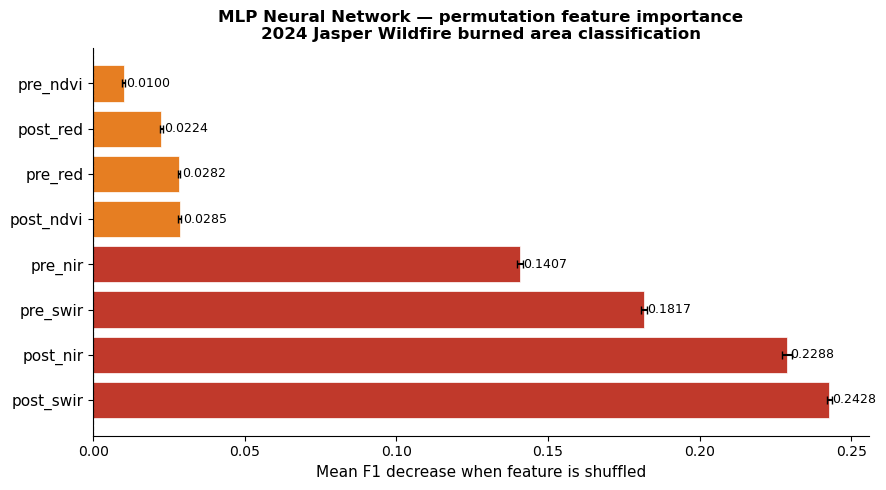

Saved: 08_mlp_permutation_importance.png

=== Feature importance — MLP (permutation) ===
  post_swir       0.2428 ± 0.0009  ████████████████████████████████████████████████
  post_nir        0.2288 ± 0.0016  █████████████████████████████████████████████
  pre_swir        0.1817 ± 0.0009  ████████████████████████████████████
  pre_nir         0.1407 ± 0.0010  ████████████████████████████
  post_ndvi       0.0285 ± 0.0005  █████
  pre_red         0.0282 ± 0.0004  █████
  post_red        0.0224 ± 0.0004  ████
  pre_ndvi        0.0100 ± 0.0004  ██


In [41]:
# 2.3.2 Feature importance for MLP — permutation importance
# Permutation importance measures accuracy drop when each feature is shuffled independently

import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

print("Computing permutation importance for MLP...")
print("(This may take ~30 seconds)")

mlp_pipe = pipelines["MLP_spectral"]

result = permutation_importance(
    mlp_pipe, X_val, y_val,
    n_repeats=10,
    random_state=42,
    scoring="f1",
    n_jobs=-1
)

importances_mean = result.importances_mean
importances_std  = result.importances_std
order            = np.argsort(importances_mean)[::-1]

colors = ["#c0392b" if importances_mean[i] > 0.05 else
          "#e67e22" if importances_mean[i] > 0.01 else
          "#3498db" for i in order]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(len(FEATURES)),
        importances_mean[order],
        xerr=importances_std[order],
        color=colors, edgecolor="white",
        linewidth=0.5, capsize=3)
ax.set_yticks(range(len(FEATURES)))
ax.set_yticklabels([FEATURES[i] for i in order], fontsize=11)
ax.set_xlabel("Mean F1 decrease when feature is shuffled", fontsize=11)
ax.set_title("MLP Neural Network — permutation feature importance\n"
             "2024 Jasper Wildfire burned area classification",
             fontsize=12, fontweight="bold")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)

for i, v in enumerate(importances_mean[order]):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(PROC / "08_mlp_permutation_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 08_mlp_permutation_importance.png")

print()
print("=== Feature importance — MLP (permutation) ===")
for i in order:
    bar = "█" * int(importances_mean[i] * 200)
    print(f"  {FEATURES[i]:<15} {importances_mean[i]:.4f} ± "
          f"{importances_std[i]:.4f}  {bar}")

### Feature Importance for Random Forest

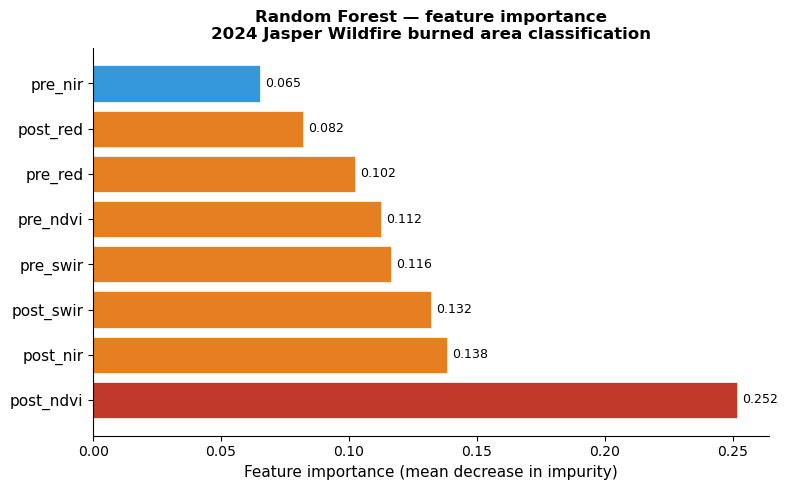

Saved: 08_rf_feature_importance.png

=== Top features (Random Forest) ===
  post_ndvi       0.2516
  post_nir        0.1384
  post_swir       0.1319
  pre_swir        0.1165
  pre_ndvi        0.1124
  pre_red         0.1022
  post_red        0.0819
  pre_nir         0.0651



In [42]:
# 2.3.3 RANDOM FOREST FEATURE IMPORTANCE
# ============================================================
import matplotlib.pyplot as plt
#import numpy as np

rf_pipe        = pipelines["RF_spectral"]
importances    = rf_pipe.named_steps["model"].feature_importances_
order          = np.argsort(importances)[::-1]

colors = ["#c0392b" if importances[i] > 0.15 else
          "#e67e22" if importances[i] > 0.08 else
          "#3498db" for i in order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(len(FEATURES)),
        importances[order],
        color=colors, edgecolor="white", linewidth=0.5)
ax.set_yticks(range(len(FEATURES)))
ax.set_yticklabels([FEATURES[i] for i in order], fontsize=11)
ax.set_xlabel("Feature importance (mean decrease in impurity)", fontsize=11)
ax.set_title("Random Forest — feature importance\n"
             "2024 Jasper Wildfire burned area classification",
             fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

for i, v in enumerate(importances[order]):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(PROC / "08_rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 08_rf_feature_importance.png")

print()
print("=== Top features (Random Forest) ===")
for i in order:
    print(f"  {FEATURES[i]:<15} {importances[i]:.4f}")
print()

# PHASE 3
**CNN Patch Classification**

The goal here is:

- Use image patches instead of per-pixel feature vectors
- Predict burned (1) vs unburned (0)
- Keep the evaluation spatially aware
- Compare CNN later against Phase 2 LR, RF, and MLP results

We’ll start with:

- Binary classification only
- 6 input channels:
  - Pre-fire: nir, swir, red
  - Post-fire: nir, swir, red
- Center pixel label = burned
- Patch size = 9 x 9

## STEP 1: Data Preparation

### Imports and Paths

In [43]:

# 3.1.0 Imports and paths
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import rasterio
from scipy.ndimage import zoom
from pathlib import Path
import time

# Paths 
PROJECT_ROOT = Path.cwd() / "alberta_burned_area_project"
PROC         = PROJECT_ROOT / "data" / "processed"
RAW          = PROJECT_ROOT / "data" / "raw"
PRE          = RAW / "pre_fire"
POST         = RAW / "post_fire"

device = torch.device("cpu")
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device}")
print(f"Threads  : {torch.get_num_threads()}")
print(f"PROC     : {PROC}")

PyTorch  : 2.10.0+cpu
Device   : cpu
Threads  : 8
PROC     : C:\Users\ifean\Jasper_2024_wildfire_assessment\alberta_burned_area_project\data\processed


### Load arrays and rater bands (bands, masks, labels)

In [44]:
# 3.1.1 Load raster bands 
# ===========================
def load_band(path):
    with rasterio.open(path) as src:
        return src.read(1).astype(np.float32)

def upsample(arr, target):
    return zoom(arr, (target.shape[0] / arr.shape[0],
                      target.shape[1] / arr.shape[1]), order=1)

print("Loading bands and masks...")
pre_nir   = load_band(PRE  / "pre_nir.tif")
pre_swir  = upsample(load_band(PRE  / "pre_swir22.tif"), pre_nir)
pre_red   = load_band(PRE  / "pre_red.tif")
post_nir  = load_band(POST / "post_nir.tif")
post_swir = upsample(load_band(POST / "post_swir22.tif"), post_nir)
post_red  = load_band(POST / "post_red.tif")

burned_mask = np.load(PROC / "burned_mask.npy")
valid_mask  = np.load(PROC / "valid_mask.npy")

H, W = pre_nir.shape
print(f"  Bands loaded  : 6  ({H} x {W} pixels)")
print(f"  Burned pixels : {int(np.nansum(burned_mask == 1)):,}")
print(f"  Valid pixels  : {int(valid_mask.sum()):,}")

Loading bands and masks...
  Bands loaded  : 6  (4515 x 4776 pixels)
  Burned pixels : 5,167,362
  Valid pixels  : 19,269,846


### Stack CNN input channels (pre/post bands)

In [45]:
# 3.1.2: Stack all 6 bands into (6, H, W) array 
# Order: pre_nir, pre_swir, pre_red, post_nir, post_swir, post_red
#==================================================================
image_stack = np.stack([
    pre_nir, pre_swir, pre_red,
    post_nir, post_swir, post_red
], axis=0).astype(np.float32)   # shape: (6, H, W)

print(f"Image stack shape : {image_stack.shape}")
print(f"  Channel 0 pre_nir   — min {image_stack[0].min():.0f}  "
      f"max {image_stack[0].max():.0f}")
print(f"  Channel 3 post_nir  — min {image_stack[3].min():.0f}  "
      f"max {image_stack[3].max():.0f}")

Image stack shape : (6, 4515, 4776)
  Channel 0 pre_nir   — min 0  max 15656
  Channel 3 post_nir  — min 0  max 15480


### Normalize Channels

In [46]:
# 3.1.3: Normalize each band to [0, 1] using 2nd–98th percentile 
# ===============================================================
def norm_band(arr):
    """Percentile clip and scale to [0, 1]. Ignore no-data zeros."""
    valid = arr[arr > 0]
    lo    = np.percentile(valid, 2)
    hi    = np.percentile(valid, 98)
    return np.clip((arr - lo) / (hi - lo + 1e-9), 0, 1).astype(np.float32)

image_stack_norm = np.stack([
    norm_band(image_stack[c]) for c in range(6)
], axis=0)

print(f"Normalized stack shape : {image_stack_norm.shape}")
print(f"  Value range per channel:")
for c, name in enumerate(["pre_nir","pre_swir","pre_red",
                           "post_nir","post_swir","post_red"]):
    ch = image_stack_norm[c]
    print(f"    {name:<12}  min={ch.min():.3f}  max={ch.max():.3f}  "
          f"mean={ch[valid_mask].mean():.3f}")

Normalized stack shape : (6, 4515, 4776)
  Value range per channel:
    pre_nir       min=0.000  max=1.000  mean=0.257
    pre_swir      min=0.000  max=1.000  mean=0.281
    pre_red       min=0.000  max=1.000  mean=0.126
    post_nir      min=0.000  max=1.000  mean=0.409
    post_swir     min=0.000  max=1.000  mean=0.302
    post_red      min=0.000  max=1.000  mean=0.226


## STEP 2 : Spatial Split + Patch Dataset Creation

### Create spatial train/validation/test masks

In [47]:
# 3.2.0 Spatial column split (64 / 16 / 20)
# Consistent with Phase 2 RF/LR column-based split
# ================================================

col_indices = np.arange(W)
train_end   = int(W * 0.64)
val_end     = int(W * 0.80)

train_col_mask = col_indices <  train_end
val_col_mask   = (col_indices >= train_end) & (col_indices < val_end)
test_col_mask  = col_indices >= val_end

print("=== Spatial column split ===")
print(f"  Image width   : {W} columns")
print(f"  Train cols    : 0       → {train_end-1:<5}  "
      f"({train_end} cols, 64%)")
print(f"  Val   cols    : {train_end} → {val_end-1:<5}  "
      f"({val_end - train_end} cols, 16%)")
print(f"  Test  cols    : {val_end} → {W-1:<5}  "
      f"({W - val_end} cols, 20%)")

=== Spatial column split ===
  Image width   : 4776 columns
  Train cols    : 0       → 3055   (3056 cols, 64%)
  Val   cols    : 3056 → 3819   (764 cols, 16%)
  Test  cols    : 3820 → 4775   (956 cols, 20%)


### Extract patches (e.g., 9×9)

In [48]:
# 3.2.1 Extract 9×9 patches with spatial labels 
# ==================================================

PATCH_SIZE = 9
STRIDE     = 9       # no overlap — avoids data leakage between patches
HALF       = PATCH_SIZE // 2

patches_X   = []
patches_y   = []
patches_col = []     # centre column of each patch — used for split

print(f"Extracting {PATCH_SIZE}×{PATCH_SIZE} patches "
      f"(stride={STRIDE})...")

for row in range(HALF, H - HALF, STRIDE):
    for col in range(HALF, W - HALF, STRIDE):

        r0, r1 = row - HALF, row + HALF + 1
        c0, c1 = col - HALF, col + HALF + 1

        # Skip patches with too many no-data pixels (>20%)
        valid_patch = valid_mask[r0:r1, c0:c1]
        if valid_patch.mean() < 0.80:
            continue

        # Extract 6-channel patch
        patch = image_stack_norm[:, r0:r1, c0:c1]

        # Label: majority vote over valid pixels in the patch
        mask_patch  = burned_mask[r0:r1, c0:c1]
        valid_pix   = mask_patch[valid_patch.astype(bool)]
        if len(valid_pix) == 0:
            continue
        label = 1 if valid_pix.mean() > 0.50 else 0

        patches_X.append(patch)
        patches_y.append(label)
        patches_col.append(col)

patches_X   = np.array(patches_X,   dtype=np.float32)
patches_y   = np.array(patches_y,   dtype=np.int64)
patches_col = np.array(patches_col, dtype=np.int32)

n_burned   = int(patches_y.sum())
n_unburned = int((patches_y == 0).sum())
print(f"  Total patches  : {len(patches_y):,}")
print(f"  Burned         : {n_burned:,}  ({100*n_burned/len(patches_y):.1f}%)")
print(f"  Unburned       : {n_unburned:,}  ({100*n_unburned/len(patches_y):.1f}%)")
print(f"  Patch shape    : {patches_X[0].shape}  (channels, H, W)")

Extracting 9×9 patches (stride=9)...
  Total patches  : 237,079
  Burned         : 59,543  (25.1%)
  Unburned       : 177,536  (74.9%)
  Patch shape    : (6, 9, 9)  (channels, H, W)


### Spatial Split + Patch Dataset Creation

In [49]:
# 3.2.2 Assign patches to train / val / test by centre column
# ===========================================================

train_idx = np.where(patches_col <  train_end)[0]
val_idx   = np.where((patches_col >= train_end) &
                     (patches_col <  val_end))[0]
test_idx  = np.where(patches_col >= val_end)[0]

print("=== Patch split ===")
for name, idx in [("Train", train_idx),
                  ("Val",   val_idx),
                  ("Test",  test_idx)]:
    n = len(idx)
    b = patches_y[idx].mean()
    print(f"  {name:<6} : {n:>7,} patches  "
          f"burned {100*b:.1f}%  unburned {100*(1-b):.1f}%")

print(f"\n  Total : {len(patches_y):,} patches")

=== Patch split ===
  Train  : 141,889 patches  burned 31.6%  unburned 68.4%
  Val    :  42,084 patches  burned 25.8%  unburned 74.2%
  Test   :  53,106 patches  burned 7.1%  unburned 92.9%

  Total : 237,079 patches


## STEP 3: CNN Model Training

### Build PyTorch Dataset + DataLoader

In [50]:
# 3.3.0 PyTorch Dataset + DataLoader
# ==========================================
class PatchDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

def make_loader(idx, balance=False, batch_size=256):
    X_s = patches_X[idx]
    y_s = patches_y[idx]
    if balance:
        # WeightedRandomSampler ensures equal burned/unburned per batch
        counts  = np.bincount(y_s)
        weights = 1.0 / counts[y_s]
        sampler = torch.utils.data.WeightedRandomSampler(
            weights=torch.tensor(weights, dtype=torch.float32),
            num_samples=len(y_s), replacement=True
        )
        return DataLoader(PatchDataset(X_s, y_s),
                          batch_size=batch_size, sampler=sampler)
    return DataLoader(PatchDataset(X_s, y_s),
                      batch_size=batch_size, shuffle=False)

train_loader = make_loader(train_idx, balance=True,  batch_size=256)
val_loader   = make_loader(val_idx,   balance=False, batch_size=256)
test_loader  = make_loader(test_idx,  balance=False, batch_size=256)

print("=== DataLoaders ready ===")
print(f"  Train batches : {len(train_loader):>5,}")
print(f"  Val   batches : {len(val_loader):>5,}")
print(f"  Test  batches : {len(test_loader):>5,}")
print(f"  Batch size    : 256")

=== DataLoaders ready ===
  Train batches :   555
  Val   batches :   165
  Test  batches :   208
  Batch size    : 256


### Define CNN architecture

In [51]:
# 3.3.1 BurnCNN architecture
# 9×9 input — no MaxPool (would reduce spatial dims too fast)
# 3 conv blocks with increasing channels → FC head
# =====================================================

class BurnCNN(nn.Module):
    """
    Custom CNN for 9×9 burned area patch classification.
    Input : (batch, 6, 9, 9)
    Output: (batch, 2) — logits for unburned / burned
    """
    def __init__(self, in_channels=6, num_classes=2):
        super().__init__()

        # Block 1: 6 → 32 channels, preserves spatial size
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # normalises the values after each convolution to keep training stable and speed up convergence
            nn.ReLU(inplace=True), # replaces any negative values with zero, 
                                # adding non-linearity so the network can learn curved decision boundaries rather than just straight lines
        )

        # Block 2: 32 → 64 channels
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        # Block 3: 64 → 128 channels
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )

        # Global average pooling — collapses 9×9 spatial to 1×1
        self.gap = nn.AdaptiveAvgPool2d(1)

        # FC classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        return self.classifier(x)

model      = BurnCNN(in_channels=6, num_classes=2).to(device)
n_params   = sum(p.numel() for p in model.parameters()
                 if p.requires_grad)

print("=== BurnCNN ===")
print(model)
print(f"\n  Trainable parameters : {n_params:,}")
print(f"  Input shape          : (batch, 6, 9, 9)")
print(f"  Output shape         : (batch, 2)")

=== BurnCNN ===
BurnCNN(
  (block1): Sequential(
    (0): Conv2d(6, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (gap): AdaptiveAvgPool2d(output_size=1)
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)

  Traina

### Train model over epochs

In [52]:
# 3.3.2 Training configuration 
# ==============================
EPOCHS    = 12
LR        = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(
                optimizer, step_size=4, gamma=0.5)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits   = model(X_b)
            loss     = criterion(logits, y_b)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y_b)
            correct    += (logits.argmax(1) == y_b).sum().item()
            total      += len(y_b)
    return total_loss / total, correct/total

### Track loss and F1

In [53]:
# 3.3.3 Run training 
# ====================================
from sklearn.metrics import f1_score

print(f"Training BurnCNN  —  {EPOCHS} epochs  |  "
      f"lr={LR}  |  batch=256  |  device={device}")
print(f"\n{'Epoch':>6} {'Tr Loss':>9} {'Tr Acc':>8} "
      f"{'Va Loss':>9} {'Va Acc':>8} {'Va F1':>7} {'Time':>6}")
print("─" * 60)

history   = []
t_total   = time.time()

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)

    # F1 on validation
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_b, y_b in val_loader:
            p = model(X_b.to(device)).argmax(1).cpu().numpy()
            preds.extend(p)
            labels.extend(y_b.numpy())
    va_f1 = f1_score(labels, preds, average="binary", zero_division=0)

    scheduler.step()
    elapsed = time.time() - t0
    history.append({"epoch": epoch, "tr_loss": tr_loss,
                    "tr_acc": tr_acc, "va_loss": va_loss,
                    "va_acc": va_acc, "va_f1": va_f1})

    print(f"  {epoch:>3}    {tr_loss:>8.4f}  {tr_acc:>7.4f}  "
          f"{va_loss:>8.4f}  {va_acc:>7.4f}  "
          f"{va_f1:>6.4f}  {elapsed:>4.0f}s")

print(f"\nTotal training time : {(time.time()-t_total)/60:.1f} min")

Training BurnCNN  —  12 epochs  |  lr=0.001  |  batch=256  |  device=cpu

 Epoch   Tr Loss   Tr Acc   Va Loss   Va Acc   Va F1   Time
────────────────────────────────────────────────────────────
    1      0.0609   0.9766    0.0406   0.9817  0.9653    34s
    2      0.0425   0.9832    0.0415   0.9819  0.9656    32s
    3      0.0376   0.9851    0.0412   0.9820  0.9659    34s
    4      0.0357   0.9857    0.0323   0.9868  0.9747    32s
    5      0.0328   0.9869    0.0270   0.9888  0.9783    33s
    6      0.0308   0.9877    0.0466   0.9805  0.9634    36s
    7      0.0303   0.9877    0.0421   0.9819  0.9659    35s
    8      0.0281   0.9887    0.0332   0.9862  0.9735    34s
    9      0.0258   0.9896    0.0326   0.9862  0.9738    34s
   10      0.0243   0.9905    0.0279   0.9885  0.9779    35s
   11      0.0257   0.9900    0.0309   0.9872  0.9755    35s
   12      0.0243   0.9903    0.0268   0.9889  0.9787    35s

Total training time : 6.8 min


### Plot training curves

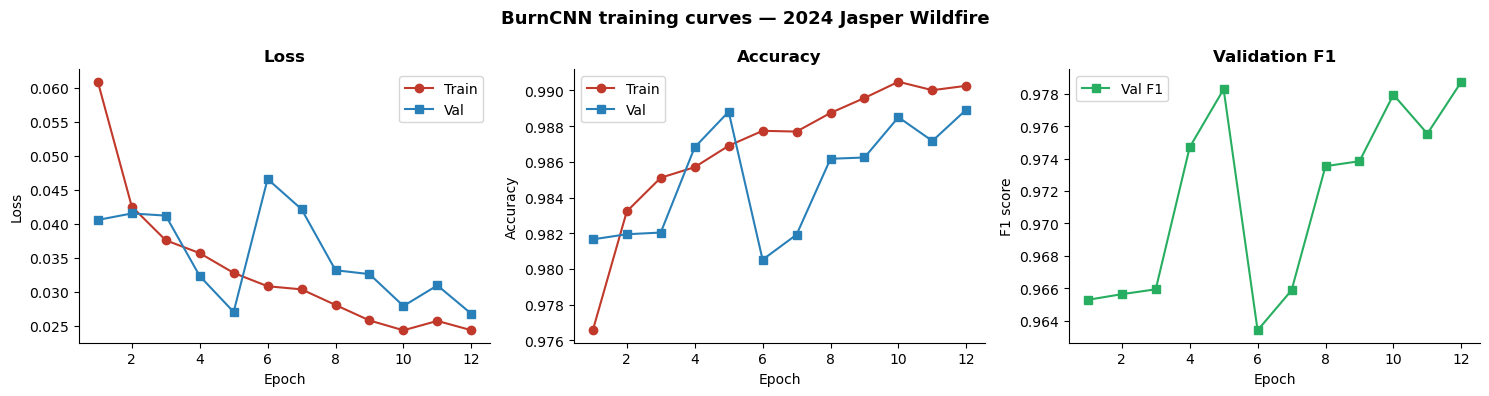

Saved: 10_cnn_training_curves.png


In [54]:
# 3.3.4 Training curves
# =====================================
import matplotlib.pyplot as plt

epochs  = [h["epoch"]   for h in history]
tr_loss = [h["tr_loss"] for h in history]
va_loss = [h["va_loss"] for h in history]
tr_acc  = [h["tr_acc"]  for h in history]
va_acc  = [h["va_acc"]  for h in history]
va_f1   = [h["va_f1"]   for h in history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, tr_loss, "o-", color="#c0392b", label="Train")
axes[0].plot(epochs, va_loss, "s-", color="#2980b9", label="Val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss", fontweight="bold")
axes[0].legend()
axes[0].spines[["top","right"]].set_visible(False)

axes[1].plot(epochs, tr_acc, "o-", color="#c0392b", label="Train")
axes[1].plot(epochs, va_acc, "s-", color="#2980b9", label="Val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy", fontweight="bold")
axes[1].legend()
axes[1].spines[["top","right"]].set_visible(False)

axes[2].plot(epochs, va_f1, "s-", color="#27ae60", label="Val F1")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("F1 score")
axes[2].set_title("Validation F1", fontweight="bold")
axes[2].legend()
axes[2].spines[["top","right"]].set_visible(False)

plt.suptitle("BurnCNN training curves — 2024 Jasper Wildfire",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PROC / "10_cnn_training_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 10_cnn_training_curves.png")

## STEP 4: Evaluation and Comparison

### Evaluate on validation set

In [55]:
# 3.4.0 Validation evaluation
# ==================================
from sklearn.metrics import (accuracy_score, f1_score,
                             cohen_kappa_score, confusion_matrix,
                             classification_report)

def eval_loader(loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            p = model(X_b.to(device)).argmax(1).cpu().numpy()
            preds.extend(p)
            labels.extend(y_b.numpy())
    return np.array(labels), np.array(preds)

y_true_val, y_pred_val = eval_loader(val_loader)

acc_val   = accuracy_score(y_true_val, y_pred_val)
f1_val    = f1_score(y_true_val, y_pred_val, average="binary")
kappa_val = cohen_kappa_score(y_true_val, y_pred_val)
cm_val    = confusion_matrix(y_true_val, y_pred_val)


print("  CNN — Validation set")
print("=" * 50)
print(f"  Accuracy      : {acc_val:.4f}  ({acc_val*100:.2f}%)")
print(f"  F1 score      : {f1_val:.4f}")
print(f"  Cohen's Kappa : {kappa_val:.4f}")
print(f"\n  Confusion matrix:")
print(f"              Pred Unburned  Pred Burned")
print(f"  True Unburned   {cm_val[0,0]:>8,}     {cm_val[0,1]:>8,}")
print(f"  True Burned     {cm_val[1,0]:>8,}     {cm_val[1,1]:>8,}")

  CNN — Validation set
  Accuracy      : 0.9889  (98.89%)
  F1 score      : 0.9787
  Cohen's Kappa : 0.9713

  Confusion matrix:
              Pred Unburned  Pred Burned
  True Unburned     30,888          325
  True Burned          141       10,730


### Final evaluation on test set

In [56]:
# 3.4.1 Test set evaluation (run ONCE — final reported metrics)
# ===============================================================
y_true_test, y_pred_cnn = eval_loader(test_loader)

acc_test   = accuracy_score(y_true_test, y_pred_cnn)
f1_test    = f1_score(y_true_test, y_pred_cnn, average="binary")
kappa_test = cohen_kappa_score(y_true_test, y_pred_cnn)
cm_test    = confusion_matrix(y_true_test, y_pred_cnn)

print("=" * 50)
print("  CNN — Final Test Set Evaluation")
print("=" * 50)
print(f"  Accuracy      : {acc_test:.4f}  ({acc_test*100:.2f}%)")
print(f"  F1 score      : {f1_test:.4f}")
print(f"  Cohen's Kappa : {kappa_test:.4f}")
print(f"\n  Confusion matrix:")
print(f"              Pred Unburned  Pred Burned")
print(f"  True Unburned   {cm_test[0,0]:>8,}     {cm_test[0,1]:>8,}")
print(f"  True Burned     {cm_test[1,0]:>8,}     {cm_test[1,1]:>8,}")
print()
print(classification_report(y_true_test, y_pred_cnn,
      target_names=["Unburned","Burned"], digits=4))

# Store for comparison table
cnn_result = {
    "model"    : "CNN (custom 9×9)",
    "accuracy" : acc_test,
    "f1"       : f1_test,
    "kappa"    : kappa_test,
    "cm"       : cm_test
}

  CNN — Final Test Set Evaluation
  Accuracy      : 0.9926  (99.26%)
  F1 score      : 0.9488
  Cohen's Kappa : 0.9448

  Confusion matrix:
              Pred Unburned  Pred Burned
  True Unburned     49,048          278
  True Burned          117        3,663

              precision    recall  f1-score   support

    Unburned     0.9976    0.9944    0.9960     49326
      Burned     0.9295    0.9690    0.9488      3780

    accuracy                         0.9926     53106
   macro avg     0.9635    0.9817    0.9724     53106
weighted avg     0.9928    0.9926    0.9926     53106



###  Compute three way model comparison: Accuracy, F1 score, Cohen's Kappa

In [57]:
# ── 3.4.2 Four-model comparison table ─────────────────────────────────────
import joblib
import pandas as pd
from sklearn.metrics import (accuracy_score, f1_score,
                             cohen_kappa_score, confusion_matrix)
import numpy as np

# Reload Phase 2 test data
df_mod   = pd.read_parquet(PROC / "pixel_dataset_modelling.parquet")

FEATURES = ["pre_nir","pre_swir","pre_red",
            "post_nir","post_swir","post_red",
            "pre_ndvi","post_ndvi"]

col_max     = df_mod["col"].max()
test_df     = df_mod[df_mod["col"] >= int(col_max * 0.80)].copy()
test_sample = test_df.sample(n=min(len(test_df), 40_000), random_state=42)
X_test_p2   = test_sample[FEATURES].values
y_test_p2   = test_sample["burned"].values

# Load all three Phase 2 pipelines
lr_pipe  = joblib.load(PROC / "phase2_LR_baseline.joblib")
rf_pipe  = joblib.load(PROC / "phase2_RF_spectral.joblib")
mlp_pipe = joblib.load(PROC / "phase2_MLP_spectral.joblib")

lr_pred  = lr_pipe.predict(X_test_p2)
rf_pred  = rf_pipe.predict(X_test_p2)
mlp_pred = mlp_pipe.predict(X_test_p2)

phase2_results = []
for name, pred in [
    ("Logistic Regression", lr_pred),
    ("Random Forest",       rf_pred),
    ("MLP Neural Network",  mlp_pred),
]:
    phase2_results.append({
        "model"    : name,
        "accuracy" : accuracy_score(y_test_p2, pred),
        "f1"       : f1_score(y_test_p2, pred, average="binary"),
        "kappa"    : cohen_kappa_score(y_test_p2, pred),
        "cm"       : confusion_matrix(y_test_p2, pred)
    })

# Combine with CNN result from Cell 14
all_results = phase2_results + [cnn_result]

print("=" * 65)
print("  FOUR-MODEL COMPARISON — Test set (spatial column split)")
print("  Features : 8 leak-free spectral bands (LR / RF / MLP)")
print("  CNN input: 9×9 patches, same spatial test block")
print("=" * 65)
print(f"  {'Model':<26} {'Accuracy':>9} {'F1':>8} {'Kappa':>8}")
print(f"  {'─'*55}")
for r in all_results:
    print(f"  {r['model']:<26} {r['accuracy']:>9.4f} "
          f"{r['f1']:>8.4f} {r['kappa']:>8.4f}")

best = max(all_results, key=lambda r: r["f1"])
print(f"\n  Best model by F1 : {best['model']}  "
      f"(F1 = {best['f1']:.4f})")
print()
print("  Note: LR/RF/MLP evaluated on pixel-level test sample (40k pixels)")
print("  CNN evaluated on patch-level test set (53,106 patches)")
print("  Both drawn from the same spatial test columns (col >= 80%)")

  FOUR-MODEL COMPARISON — Test set (spatial column split)
  Features : 8 leak-free spectral bands (LR / RF / MLP)
  CNN input: 9×9 patches, same spatial test block
  Model                       Accuracy       F1    Kappa
  ───────────────────────────────────────────────────────
  Logistic Regression           0.9783   0.8830   0.8711
  Random Forest                 0.9779   0.8838   0.8716
  MLP Neural Network            0.9973   0.9854   0.9839
  CNN (custom 9×9)              0.9926   0.9488   0.9448

  Best model by F1 : MLP Neural Network  (F1 = 0.9854)

  Note: LR/RF/MLP evaluated on pixel-level test sample (40k pixels)
  CNN evaluated on patch-level test set (53,106 patches)
  Both drawn from the same spatial test columns (col >= 80%)


### Side-by-side bar chart

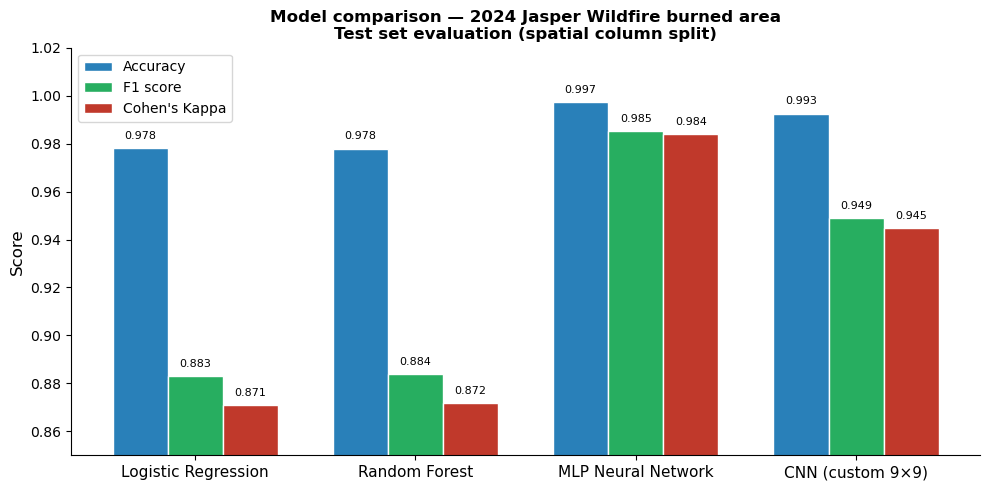

Saved: 11_model_comparison.png


In [58]:
# 3.4.3 Model comparison bar chart 
# =====================================

import matplotlib.pyplot as plt
import numpy as np

models   = [r["model"] for r in all_results]
accuracy = [r["accuracy"] for r in all_results]
f1s      = [r["f1"]      for r in all_results]
kappas   = [r["kappa"]   for r in all_results]

x      = np.arange(len(models))
width  = 0.25
colors = ["#2980b9", "#27ae60", "#c0392b"]

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width, accuracy, width, label="Accuracy",
            color=colors[0], edgecolor="white")
b2 = ax.bar(x,          f1s,     width, label="F1 score",
            color=colors[1], edgecolor="white")
b3 = ax.bar(x + width,  kappas,  width, label="Cohen's Kappa",
            color=colors[2], edgecolor="white")

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f"{h:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_ylabel("Score", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0.85, 1.02)
ax.set_title("Model comparison — 2024 Jasper Wildfire burned area\n"
             "Test set evaluation (spatial column split)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(PROC / "11_model_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 11_model_comparison.png")

### Confusion Matrices

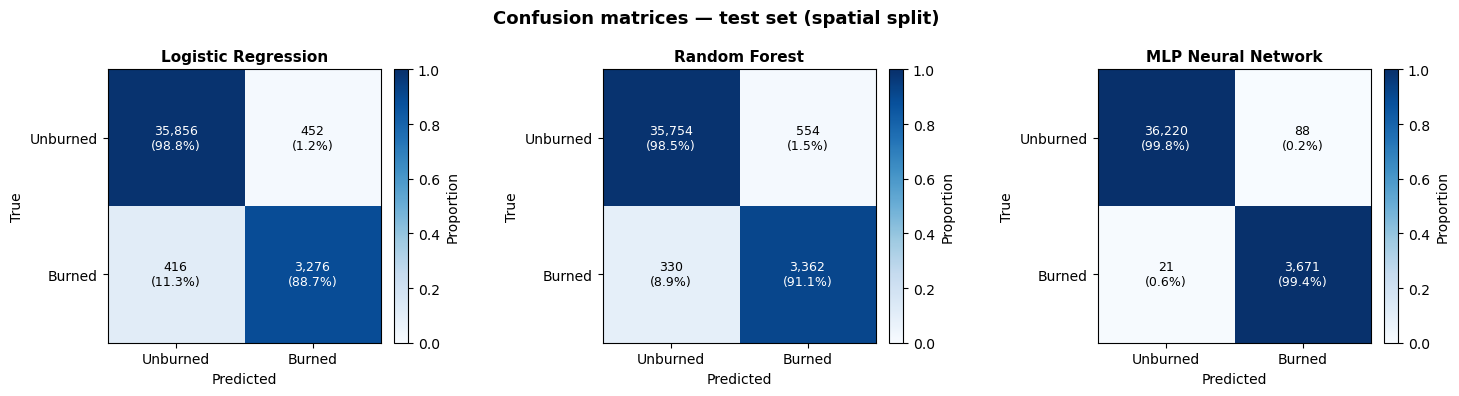

Saved: 12_confusion_matrices.png

PHASE 3 COMPLETE
Outputs saved:
  10_cnn_training_curves.png
  10_rf_validation_curve.png
  11_model_comparison.png
  12_confusion_matrices.png


In [59]:
# 3.4.4 Confusion matrices — one per model
# =========================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cmap = plt.cm.Blues

for ax, r in zip(axes, all_results):
    cm   = r["cm"]
    # Normalize by row (true label) for percentages
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Unburned","Burned"], fontsize=10)
    ax.set_yticklabels(["Unburned","Burned"], fontsize=10)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)
    ax.set_title(r["model"], fontsize=11, fontweight="bold")

    # Annotate cells with count and percentage
    for i in range(2):
        for j in range(2):
            ax.text(j, i,
                    f"{cm[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)",
                    ha="center", va="center", fontsize=9,
                    color="white" if cm_norm[i,j] > 0.6 else "black")

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 label="Proportion")

plt.suptitle("Confusion matrices — test set (spatial split)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PROC / "12_confusion_matrices.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 12_confusion_matrices.png")
print()
print("=" * 55)
print("PHASE 3 COMPLETE")
print("=" * 55)
print("Outputs saved:")
for f in sorted(PROC.glob("1[0-2]_*.png")):
    print(f"  {f.name}")

In [67]:
# ── Check all_results contains 4 models ───────────────────────────────────
print(f"Number of models in all_results: {len(all_results)}")
for r in all_results:
    print(f"  {r['model']}")

Number of models in all_results: 4
  Logistic Regression
  Random Forest
  MLP Neural Network
  CNN (custom 9×9)


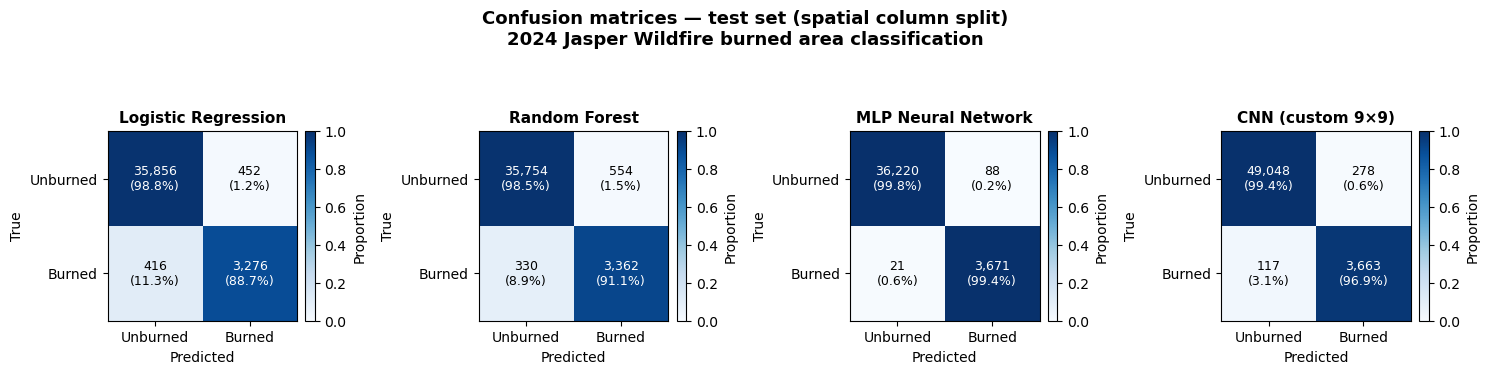

Saved: 12_confusion_matrices.png

PHASE 3 COMPLETE

Output files saved:
  10_cnn_training_curves.png
  10_rf_validation_curve.png
  11_model_comparison.png
  12_confusion_matrices.png

All phases complete:
  Phase 1 — Data preprocessing          
  Phase 2 — LR, RF, MLP training        
  Phase 3 — CNN training + comparison   


In [68]:
# ── Cell 17: Confusion matrices — 4 models ────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, r in zip(axes, all_results):
    cm      = r["cm"]
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap=plt.cm.Blues, vmin=0, vmax=1)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Unburned", "Burned"], fontsize=10)
    ax.set_yticklabels(["Unburned", "Burned"], fontsize=10)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)
    ax.set_title(r["model"], fontsize=11, fontweight="bold")

    for i in range(2):
        for j in range(2):
            ax.text(j, i,
                    f"{cm[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)",
                    ha="center", va="center", fontsize=9,
                    color="white" if cm_norm[i,j] > 0.6 else "black")

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 label="Proportion")

plt.suptitle("Confusion matrices — test set (spatial column split)\n"
             "2024 Jasper Wildfire burned area classification",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PROC / "12_confusion_matrices.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 12_confusion_matrices.png")
print()
print("=" * 55)
print("PHASE 3 COMPLETE")
print("=" * 55)
print()
print("Output files saved:")
for f in sorted(PROC.glob("1[0-2]_*.png")):
    print(f"  {f.name}")
print()
print("All phases complete:")
print("  Phase 1 — Data preprocessing          ")
print("  Phase 2 — LR, RF, MLP training        ")
print("  Phase 3 — CNN training + comparison   ")